### Projet d'Econometrie : Marius Calaque



### Introduction

Pour ce projet d'économétrie, nous avons choisi d'étudier les corrélations entre le cours de l'or et les taux d'intérêt obligataires américains à 10 ans (Taux US 10Y).

L’or est un métal précieux qualifié de valeur refuge, c'est-à-dire qu'il reste stable, ou qu'il prend de la valeur, en périodes d’incertitude économique ou de volatilité des marchés boursiers. Historiquement, les agents économiques utilisent l’or pour se protéger contre les risques d’inflation, les crises économiques, et les chocs géopolitiques. Autrement dit, l'or permet de se hedger contre le risque systémique. Le cours de l'or fait l'objet d'une surveillance particulière par les analystes sur les marchés financiers. Une hausse de son prix peut révéler l'inquiétude du marché et des tensions économiques à venir.


Dans un premier temps, nous étudierons les cours de l'or et des taux US 10Y.



###Partie 1 : modélisation univariée



### I) Choix des séries temporelles
Les taux US 10Y représentent le rendement des obligations du Trésor américain sur une période de dix ans. Ces taux servent d’indicateur de référence pour de nombreux autres taux d’intérêt. Le rendement à 10 ans est considéré comme une preuve de la confiance des investisseurs dans l’économie à long terme. Moins les investisseurs ont confiance à long terme, plus ils se réfugient dans les obligations, faisant monter leur cours, mais baisser leur rendement. Ainsi, plus les taux sont bas, plus  les attentes de croissance sont faibles. À l’inverse, des taux élevés suggèrent des anticipations de croissance, les investisseurs vendent leurs obligations, ce qui cause une augmentation des taux 10Y.

Hypothèse : Si le cours de l'or augmente en période d'incertitude et que les taux US 10Y diminuent lorsque que les investisseurs perdent confiance en l'économie, nous devrions avoir une corrélation négative entre le cours de l'or et le cours des taux US 10Y.

Echantillon : Pour réaliser notre étude, nous avons extrait de Yahou Finance les données mensuelles des cours de l'or et des taux US 10Y de janvier 1990 à mai 2024, soit N = 413.

### I) Analyse des graphiques des séries

In [ ]:
# QUESTION 1

# Chargement des données
# Installer le package readxl si nécessaire
if (!require(readxl)) {
  install.packages("readxl", dependencies = TRUE)
}
library(readxl)

# Chargement des fichiers -> ils sont téléchargés sur le colab dans fichier (onglet à gauche) en xlsx sinon ils s'ouvrent pas
file_path_rate <- "/content/Rate10Y.xlsx"
file_path_gold <- "/content/Gold.xlsx"
file_path_spx <- "/content/Spx.xlsx"

# Lecture des deux fichiers et création des vecteurs
db_rate <- read_excel(file_path_rate, sheet = "Feuil1", col_names = TRUE)
db_gold <- read_excel(file_path_gold, sheet = "Feuil1", col_names = TRUE)
db_spx <- read_excel(file_path_spx, sheet = "Feuil1", col_names = TRUE)

dates <- db_spx[[1]] # dedans il y a les dates mais ATTENTION au format, je crois qu'il y a des problèmes
rate_data <- db_rate[[2]] # dedans il y a les clôtures des taux de janv 1990 à mai 2024 (413 lignes, 1 colonne)
gold_gold <- db_gold[[2]] # dedans il y a les clôtures de l'or de janv 1990 à mai 2024 (413 lignes, 1 colonne)

# Affichage juste pour vérifier
#print(dates)
#print(rate_data)
#print(gold_data)

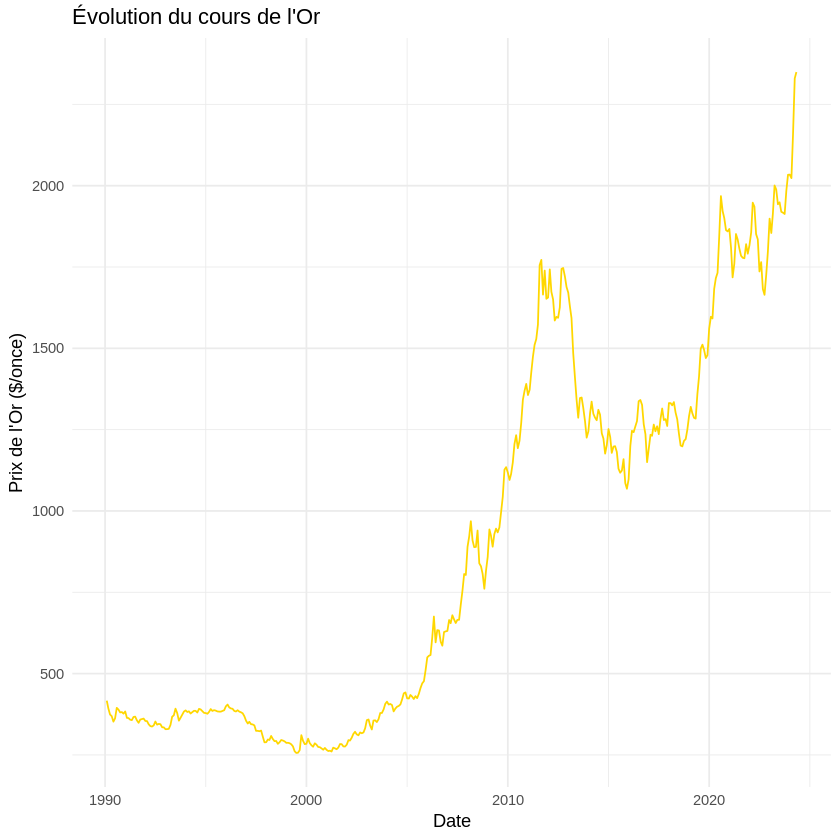

In [ ]:
#Représentation du cours de l'or

# Créer le data frame data_gold à partir de db_gold et renommer les colonnes
data_gold <- db_gold
names(data_gold) <- c("Date", "Gold")  # Renomme les colonnes en "Date" et "Gold"

# Convertir la colonne Date en format Date (si elle est au format Excel, utilisez origin)
data_gold$Date <- as.Date(data_gold$Date, origin = "1899-12-30")

# Convertir la colonne Gold en numérique
data_gold$Gold <- as.numeric(data_gold$Gold)

# Filtrer les lignes avec des valeurs manquantes
data_gold <- data_gold[!is.na(data_gold$Date) & !is.na(data_gold$Gold), ]

# Charger ggplot2 si nécessaire
if (!require(ggplot2)) {
  install.packages("ggplot2", dependencies = TRUE)
}
library(ggplot2)

# Tracer le graphique
plot_gold <- ggplot(data_gold, aes(x = Date, y = Gold)) +
  geom_line(color = "gold") +
  labs(title = "Évolution du cours de l'Or", x = "Date", y = "Prix de l'Or ($/once)") +
  theme_minimal()

# Afficher le graphique
print(plot_gold)


Le graphique montre l'évolution du prix de l'or de janvier 1990 à mai 2024. De 1990 aux années 2000, le prix reste stable dans un contexte de développement économique, surtout dans le secteur technologique. À partir de 2000, lorsque la bulle internet éclate, l'or augmente progressivement,puis exponentiellement atteignant 1000 dollars en 2008, en raison de la crise financière mondiale et de la demande pour des valeurs refuges. De 2008 à 2011, l'or connaît une forte hausse, dépassant les 1800 dollars, alimentée par la crise économique. Après 2011, le prix baisse puis se stabilise autour de 1200 dollars. Depuis 2020, l'or atteint de nouveaux records, dépassant les 2000 dollars, en réponse à la pandémie de COVID-19, à l'inflation et aux tensions géopolitiques. Ces hausses reflètent le rôle de l'or comme valeur refuge en période d'incertitude économique.

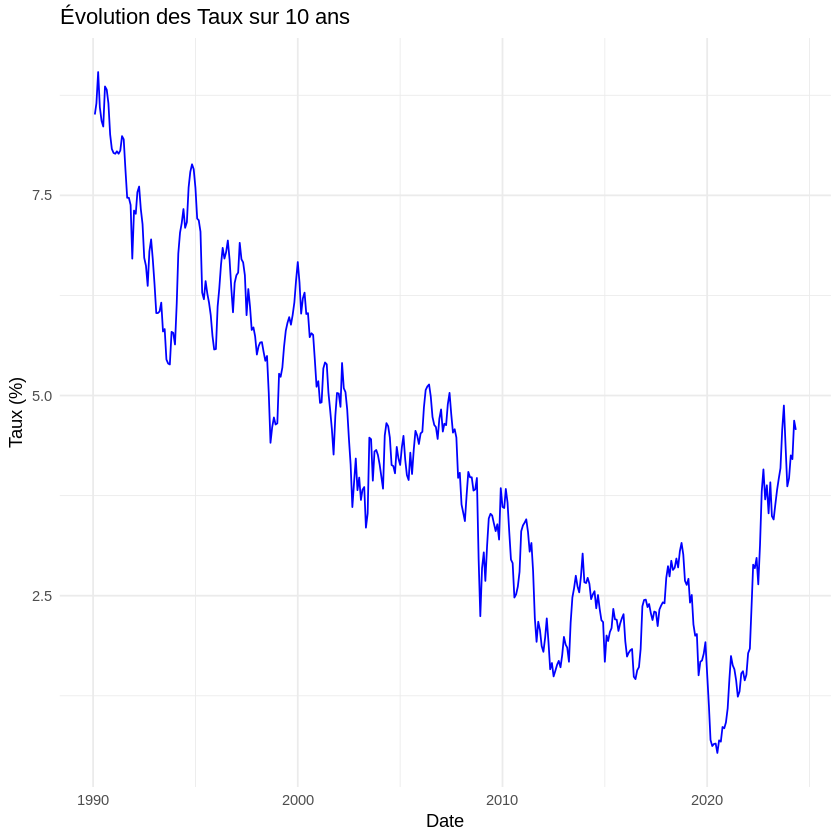

In [ ]:
# Représentation cours des taux US 10Y

# Créer le data frame data_rate à partir de db_rate et renommer les colonnes
data_rate <- db_rate
names(data_rate) <- c("Date", "Rate")  # Renomme les colonnes en "Date" et "Rate"

# Convertir la colonne Date en format Date (si elle est au format Excel, utilisez origin)
data_rate$Date <- as.Date(data_rate$Date, origin = "1899-12-30")

# Convertir la colonne Rate en numérique
data_rate$Rate <- as.numeric(data_rate$Rate)

# Filtrer les lignes avec des valeurs manquantes
data_rate <- data_rate[!is.na(data_rate$Date) & !is.na(data_rate$Rate), ]

# Vérifier que les données ne sont pas vides
if (nrow(data_rate) > 0) {
  # Tracer le graphique des Taux
  plot_rate <- ggplot(data_rate, aes(x = Date, y = Rate)) +
    geom_line(color = "blue") +
    labs(title = "Évolution des Taux sur 10 ans", x = "Date", y = "Taux (%)") +
    theme_minimal()

  # Afficher le graphique
  print(plot_rate)
} else {
  print("Les données des Taux sont vides après le filtrage.")
}



Le graphique montre l'évolution des taux US 10Y de janvier 1990 à mai 2024. La tendance globale montre une baisse des taux de 1990 à 2020. Cependant, on remarque certaines variations plus importantes sur certaines périodes. Avant la crise internet en 2000, on remarque une rapide augmentation des taux, qui témoigne de la confiance des investisseurs et de la formation d'une bulle. Après l'explosion de la bulle, les taux rechutent violemment. Ils remontent légèrement jusqu'en 2008 où là encore, après la crise des subprimes, ils rechutent violemment. Les taux évoluent dans un range entre 3% et 1% de 2010 jusqu'au covid en 2019. Enfin, les taux chutent violemment de 2019 à 2020 avant de connaître une hausse fulgurante de 5 points de % entre 2021 et 2024.
Les hausses des taux révèlent la confiance des investisseurs avant les différentes crises, mais aussi préviennent de l'éclatement d'une bulle.
Une question subsiste quant à la dernière hausse taux, plus forte augmentation depuis 1990. Les craintes d'une récession partagée par les économistes semblent se confirmer à la vue de ce graphique.

### II) Autocorrélogrammes des séries

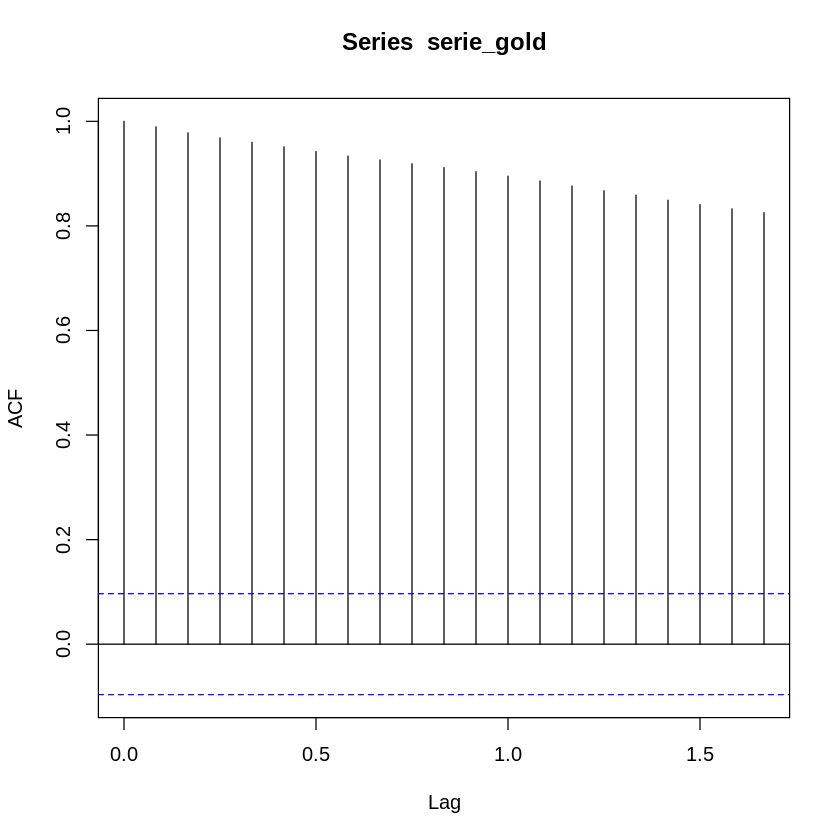

In [ ]:
# Conversion des données de clôture de l'or en numérique
gold_data_numeric <- as.numeric(data_gold$Gold)

# Création de la série temporelle pour les données mensuelles de janvier 1990 à mai 2024 (fréquence = 12 pour des données mensuelles)
serie_gold <- ts(gold_data_numeric, start = c(1990, 1), frequency = 12)

# Charger le package forecast si nécessaire
if (!require(forecast)) {
  install.packages("forecast", dependencies = TRUE)
}
library(forecast)

# Calculer et afficher l'ACF de la série temporelle
acf(serie_gold, lag.max = 20)


L'autocorrélogramme du cours de l'or montre que les lags décroissent très lentement. On en déduit que la série n'est pas stationnaire.

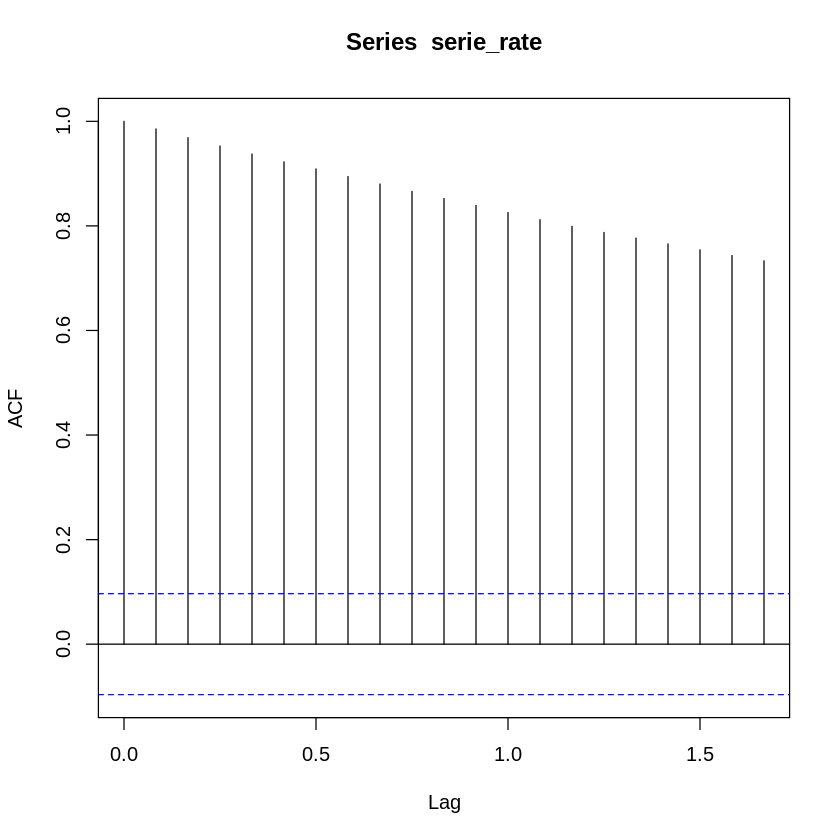

In [ ]:
# Conversion des données de clôture des taux en numérique
rate_data_numeric <- as.numeric(data_rate$Rate)

# Création de la série temporelle pour les données mensuelles de janvier 1990 à mai 2024 (fréquence = 12 pour des données mensuelles)
serie_rate <- ts(rate_data_numeric, start = c(1990, 1), frequency = 12)

# Calculer et afficher l'ACF de la série temporelle
acf(serie_rate, lag.max = 20)


L'autocorrélogramme du cours des taux US 10Y montre que les lags décroissent très lentement. On en déduit que la série n'est pas stationnaire.

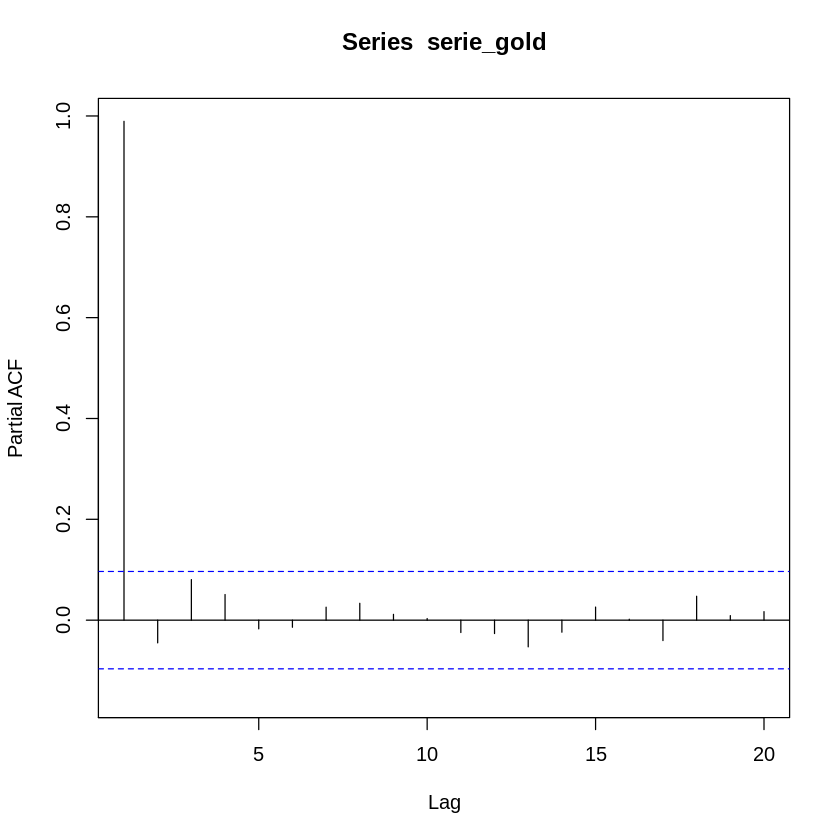

In [ ]:
Pacf(serie_gold, lag.max = 20)

L'autocorrélogramme partiel du cours de l'or montre une violente chute à partir du deuxième lag.

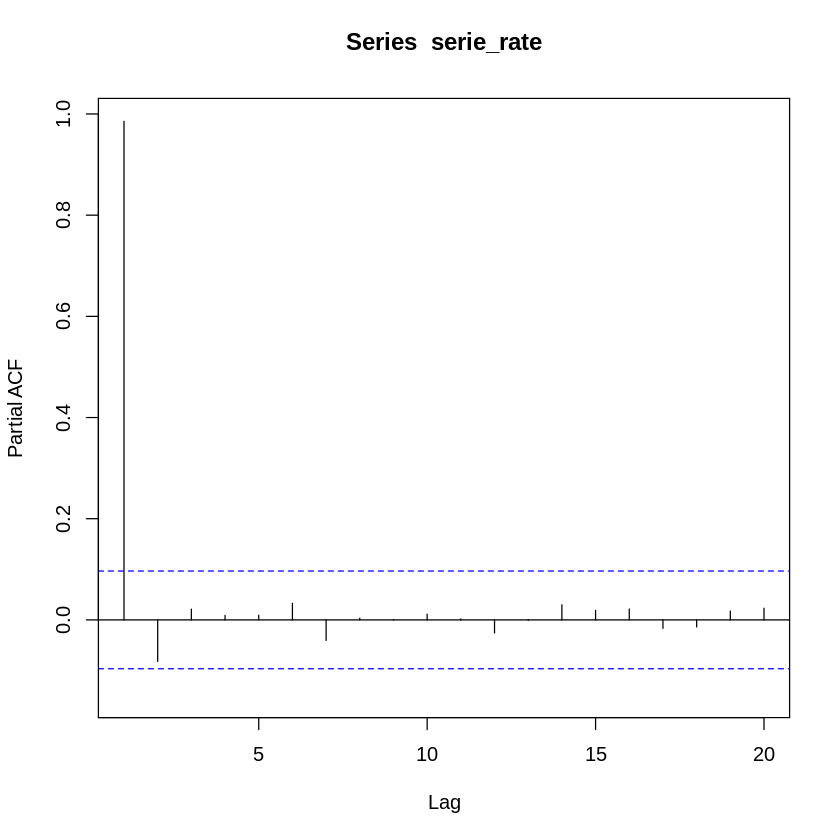

In [ ]:
Pacf(serie_rate, lag.max = 20)

L'autocorrélogramme partiel du cours des taux US 10Y montre une violente chute à partir du deuxième lag.

### III) Test de racine unitaire sur chaque série
#### A) Test sur la série de l'or
#### 1) Test ADF sur l'or

In [ ]:
#ADF de la série de l'or avec tendance et constante
if (!require(tseries)) {
  install.packages("tseries", dependencies = TRUE)
}
library(tseries)

if (!require(urca)) {
  install.packages("urca", dependencies = TRUE)
}
library(urca)

adf1 <- ur.df(y = serie_gold, type = "trend", selectlags = "AIC")
summary(adf1)

Loading required package: urca




############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-116.092  -14.472   -1.637   10.890  173.388 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.108073   3.568522  -0.591   0.5550    
z.lag.1     -0.011156   0.007232  -1.543   0.1237    
tt           0.076055   0.035042   2.170   0.0306 *  
z.diff.lag   0.218687   0.048540   4.505 8.68e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 35.87 on 406 degrees of freedom
Multiple R-squared:  0.06231,	Adjusted R-squared:  0.05538 
F-statistic: 8.992 on 3 and 406 DF,  p-value: 8.869e-06


Value of test-statistic is: -1.5426 3.3435 2.826 

Critical values for test statistics: 
      1pct  5pct 10pct
tau3 -3.98 -3.42 -3.13


#### Hypothèses
Hypothèse nulle (H₀) : La série a une racine unitaire (non stationnaire).`

Hypothèse alternative (H₁) : La série est stationnaire.

#### Analyse des coefficients

#### z.lag.1 :
Coefficient = -0.011156
T_statistique = -1.543
P_value = 0.1237
Ce coefficient correspond à la variable retardée z_{t-1}, et il est crucial pour rejeter H₀.
Ici, la valeur absolue de la statistique de test n'est pas assez grande pour dépasser les seuils critiques (-3.98, -3.42, -3.13), donc nous ne pouvons pas rejeter H₀.

#### Tendance temporelle (tt) :
Coefficient = 0.076055
T_statistique = 2.170
P_value = 0.0306
La tendance temporelle est significative, indiquant que la série semble présenter une tendance linéaire.

#### z.diff.lag :
Coefficient = 0.218687
T_statistique = 4.505
P_value = 8.68e-06
Le retard de la différence est significatif, ce qui aide à capturer la dynamique des retards.

#### Statistiques des tests ADF

#### Valeur de la statistique de test (τ) :
tau_statistique = -1.543
Comparée aux seuils critiques (-3.98, -3.42, -3.13), cette valeur est bien au-dessus.
Cela implique que nous ne pouvons pas rejeter l'hypothèse nulle de non-stationnarité
au niveau de signification de 1 %, 5 %, ou même 10 %.

#### Valeur de ϕ :
phi2, phi3 = 3.3435, 2.826
Les valeurs calculées pour ϕ2 et ϕ3 sont inférieures aux seuils critiques (par exemple, ϕ3 : 8.34, 6.30, 5.36).
Cela confirme également que la série présente une non-stationnarité structurelle avec une tendance.

#### R² et Signification Globale

R2_ajuste = 0.05538
Cela indique que le modèle n'explique qu'une très petite fraction de la variabilité de z.diff.

F_statistique = 8.992
P_value = 8.869e-06
Globalement, le modèle est significatif, mais cela peut être dû à la tendance temporelle.

#### Conclusion

La série semble non stationnaire, même en tenant compte d'une tendance.
La statistique τ n'est pas suffisante pour rejeter H₀.
La présence d’une tendance significative suggère que la non-stationnarité est en partie due à une composante déterministe. Nous avons un processus TS

#### Pour stationnariser la série, vous pourriez envisager de :
- Différencier davantage pour éliminer la racine unitaire.
- Retirer la tendance déterministe (par exemple, dé-trender).


#### 2) Test KPSS sur la série de l'or

In [ ]:
# Charger le package
library(tseries)

# Effectuer le test KPSS
kpss_result <- kpss.test(serie_gold, null = "Level", lshort = TRUE) # Test pour stationnarité au niveau
print(kpss_result)

# Si vous souhaitez tester la stationnarité autour d'une tendance :
kpss_result_trend <- kpss.test(serie_gold, null = "Trend", lshort = TRUE)
print(kpss_result_trend)

Warning message in kpss.test(serie_gold, null = "Level", lshort = TRUE):
“p-value smaller than printed p-value”



	KPSS Test for Level Stationarity

data:  serie_gold
KPSS Level = 6.0528, Truncation lag parameter = 5, p-value = 0.01



Warning message in kpss.test(serie_gold, null = "Trend", lshort = TRUE):
“p-value smaller than printed p-value”



	KPSS Test for Trend Stationarity

data:  serie_gold
KPSS Trend = 0.72954, Truncation lag parameter = 5, p-value = 0.01



#### Résultats du test KPSS pour la stationnarité au niveau

Statistique KPSS : 6.0528
P-value : 0.01
Hypothèse nulle : La série est stationnaire au niveau.
Conclusion : La statistique KPSS est très élevée et la p-value est inférieure au seuil critique (alpha = 0.05), donc nous rejetons l'hypothèse nulle. Cela indique que la série n'est pas stationnaire au niveau.

#### Résultats du test KPSS pour la stationnarité avec tendance

Statistique KPSS : 0.72954
P-value : 0.01
Hypothèse nulle : La série est stationnaire autour d'une tendance déterministe.
Conclusion : La statistique KPSS est élevée et la p-value est significative (<= 0.01), ce qui signifie que nous rejetons également l'hypothèse nulle. Cela indique que la série n'est pas stationnaire autour d'une tendance.

#### Analyse et recommandations

Stationnarité au niveau : La série 'serie_gold' présente une non-stationnarité au niveau, ce qui peut être lié à une tendance ou une racine unitaire.
Stationnarité avec tendance : Même après avoir pris en compte une éventuelle tendance, la série reste non stationnaire.

Ainsi le KPSS est consistent avec l'analyse de ADF qui montre que l'or est bien une série non stationnaire.


#### 3) Detrend de la série de l'or

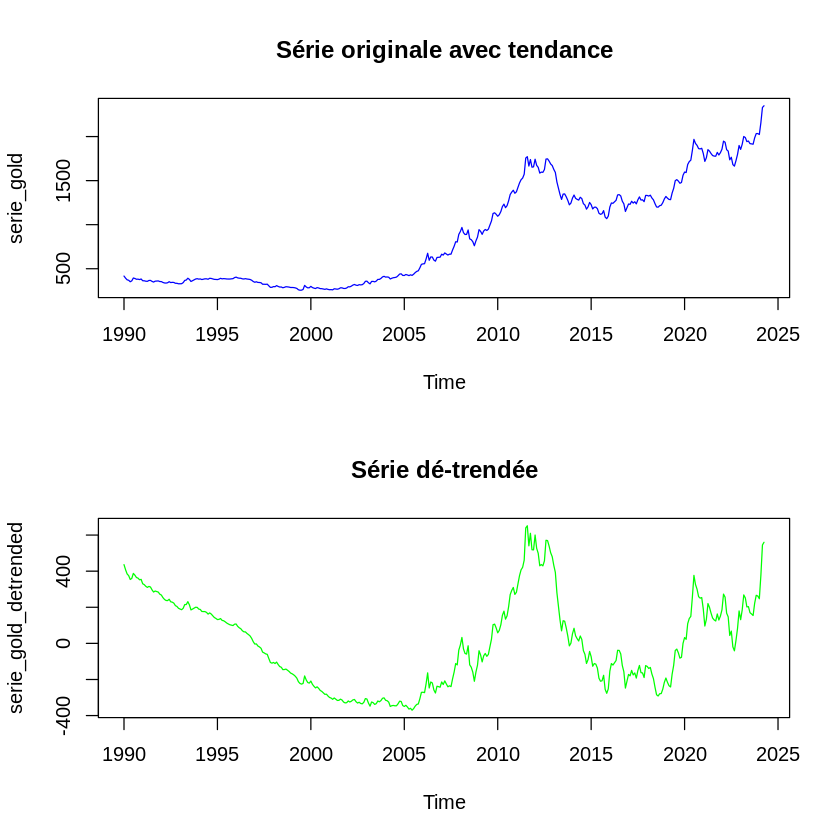

In [ ]:
# Supposons que 'serie_gold' soit la série temporelle

# Étape 1 : Créer un index temporel
time_index <- 1:length(serie_gold)

# Étape 2 : Estimer la tendance par MCO
trend_model <- lm(serie_gold ~ time_index)  # Ajustement par régression linéaire

# Étape 3 : Extraire la tendance estimée
trend_estimated <- trend_model$fitted.values  # Valeurs ajustées (tendance estimée)

# Étape 4 : Dé-trender la série
serie_gold_detrended <- serie_gold - trend_estimated  # Série dé-trendée

# Étape 5 : Visualisation
par(mfrow = c(2, 1))
plot(serie_gold, type = "l", col = "blue", main = "Série originale avec tendance")
lines(trend_estimated, col = "red", lwd = 2, lty = 2)  # Ajouter la tendance estimée
plot(serie_gold_detrended, type = "l", col = "green", main = "Série dé-trendée")
par(mfrow = c(1, 1))  # Réinitialiser l'affichage des graphiques


#### 4) Test de ADF et KPSS pour la série de l'or detrendé

La série, même après la supression de la trend, n'est toujours pas stationnaire, nous allons procéder à une différenciation première


Warning message in adf.test(serie_gold_diff, alternative = "stationary"):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  serie_gold_diff
Dickey-Fuller = -7.5073, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary



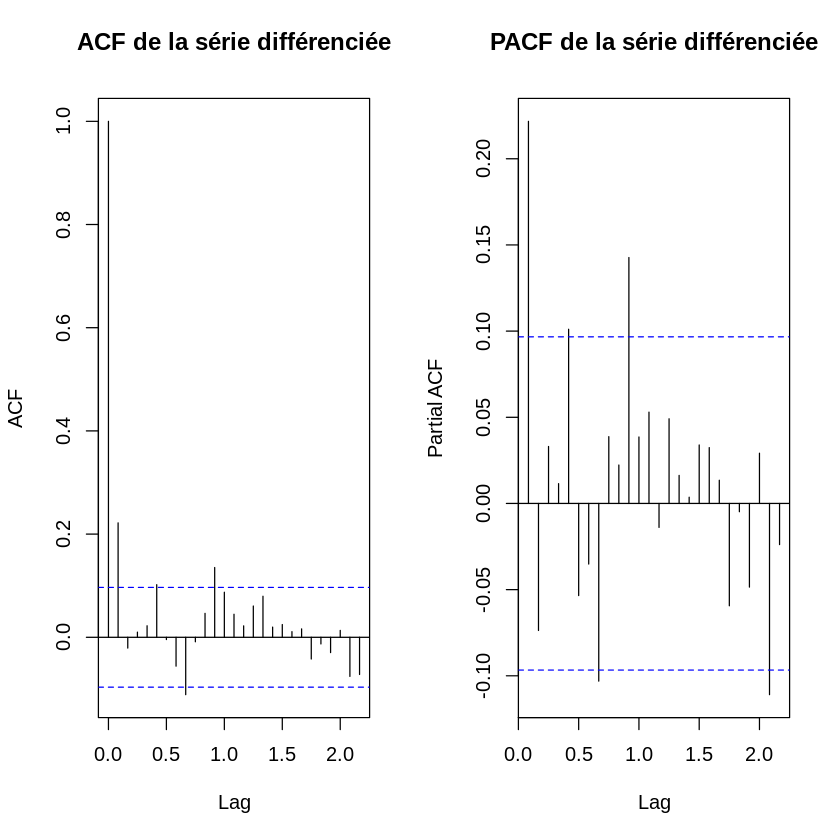

In [ ]:
# Appliquer une différenciation sur la série dé-trendée
serie_gold_diff <- diff(serie_gold_detrended)

# Vérifier la stationnarité avec le test ADF
adf_result_diff <- adf.test(serie_gold_diff, alternative = "stationary")
print(adf_result_diff)

par(mfrow = c(1, 2))
acf(serie_gold_diff, main = "ACF de la série différenciée")
pacf(serie_gold_diff, main = "PACF de la série différenciée")
par(mfrow = c(1, 1))

### Résultats du test Augmented Dickey-Fuller (ADF)

Statistique Dickey-Fuller : -7.5073
Lag order : 7
P-value : <= 0.01
Hypothèse alternative : La série est stationnaire.

### Interprétation des résultats

La statistique Dickey-Fuller de -7.5073 est très négative et bien inférieure aux seuils critiques habituels (par exemple, -3.43 pour 5 %, -3.14 pour 10 %). Cela indique que nous rejetons l'hypothèse nulle (H₀) selon laquelle la série possède une racine unitaire (non stationnaire). La p-value, inférieure à 0.01, confirme également que nous rejetons H₀ au niveau de signification de 1 %.

### Conclusion

La série `serie_gold_diff` est devenue stationnaire après différenciation et detrend. Les transformations appliquées (par exemple, dé-trending et différenciation) ont réussi à éliminer la non-stationnarité. Cette série peut maintenant être utilisée pour des modèles ou des analyses nécessitant une stationnarité.

In [ ]:
# Test KPSS sur la série différenciée
kpss_diff <- kpss.test(serie_gold_diff, null = "Level", lshort = TRUE)
print("Résultats du test KPSS pour la série différenciée (stationnarité au niveau) :")
print(kpss_diff)


[1] "Résultats du test KPSS pour la série différenciée (stationnarité au niveau) :"

	KPSS Test for Level Stationarity

data:  serie_gold_diff
KPSS Level = 0.39872, Truncation lag parameter = 5, p-value = 0.07771



Le test de KPSS est consistant avec notre observation dans le test de Dickey-Fuller, ainsi la série est belle est bien devenue stationnaire.

### B) Test sur la série des taux
#### 1) Test ADF sur les taux

In [ ]:
#Test ADF avec constante et tendance
adf4 <- ur.df(y = serie_rate, type = "trend", selectlags = "AIC")
summary(adf4)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.02228 -0.16472  0.00661  0.14503  0.89816 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept)  0.1917028  0.1038720   1.846   0.0657 .
z.lag.1     -0.0321334  0.0138699  -2.317   0.0210 *
tt          -0.0003173  0.0002315  -1.371   0.1713  
z.diff.lag   0.1157241  0.0499946   2.315   0.0211 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2598 on 406 degrees of freedom
Multiple R-squared:  0.02762,	Adjusted R-squared:  0.02043 
F-statistic: 3.843 on 3 and 406 DF,  p-value: 0.009823


Value of test-statistic is: -2.3168 2.6423 3.7164 

Critical values for test statistics: 
      1pct  5pct 10pct
tau3 -3.98 -3.42 -3.13
phi2


#### Modèle 3 ###

Modèle estimé : régression incluant une constante, une tendance déterministe et des différences retardées.

### Résultats des coefficients :
--------------------------------------------------
(Intercept) : 0.1917 (p-value : 0.0657)
z.lag.1     : -0.0321 (p-value : 0.0210)
tt          : -0.0003 (p-value : 0.1713)
z.diff.lag  : 0.1157 (p-value : 0.0211)

###Statistique de test pour la racine unitaire :
--------------------------------------------------
Statistique de test : -2.3168
Valeurs critiques (tau3) : -3.98 (1%), -3.42 (5%), -3.13 (10%)

#### Conclusion :
L'hypothèse nulle de racine unitaire NE PEUT PAS être rejetée.
La série n'est pas un modèle 3 au sens de Dickey-Fuller

#### Analyse de la tendance dans le test ADF

Modèle estimé avec tendance déterministe incluse (variable : tt).

####Résultats pour la tendance (tt) :
--------------------------------------------------
Coefficient estimé : -0.0003
Erreur standard    : 0.0002
t-statistique      : -1.371
p-value            : 0.1713

####Interprétation :
--------------------------------------------------
La p-value associée à la tendance est supérieure au seuil de significativité usuel (5 %), ce qui indique que la tendance n'est pas significativement différente de zéro dans ce modèle.

Cela suggère que la tendance déterministe n'a pas d'effet significatif sur la dynamique de la série temporelle. En d'autres termes, la présence d'une tendance linéaire n'est pas nécessaire pour capturer les variations de la série.

####Implications pour la stationnarité :
--------------------------------------------------
- Malgré l'inclusion de la tendance, la série reste non stationnaire car la statistique de test pour la racine unitaire (\( z.lag.1 \)) ne dépasse pas les seuils critiques pour rejeter l'hypothèse nulle.
- La faible significativité de la tendance pourrait indiquer qu'une transformation supplémentaire, comme la différenciation, est nécessaire pour stationnariser la série sans modéliser explicitement une tendance.

####Conclusion :
--------------------------------------------------
La tendance déterministe incluse dans ce modèle ne joue pas un rôle significatif. Par conséquent, elle n'est probablement pas un élément clé de la structure de la série. Une modélisation alternative sans tendance pourrait être envisagée pour simplifier l'analyse.


In [ ]:
#Test ADF avec constante
adf5 <- ur.df(y = serie_rate, type = "drift", selectlags = "AIC")
summary(adf5)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.02212 -0.16325  0.00827  0.14478  0.92653 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept)  0.055514   0.030278   1.834   0.0675 .
z.lag.1     -0.015351   0.006521  -2.354   0.0190 *
z.diff.lag   0.101743   0.048995   2.077   0.0385 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2601 on 407 degrees of freedom
Multiple R-squared:  0.02312,	Adjusted R-squared:  0.01832 
F-statistic: 4.816 on 2 and 407 DF,  p-value: 0.00857


Value of test-statistic is: -2.3543 3.0178 

Critical values for test statistics: 
      1pct  5pct 10pct
tau2 -3.44 -2.87 -2.57
phi1  6.47  4.61  3.79


### Modèle 2 ###

Statistique Dickey-Fuller : -2.3168
Valeurs critiques (tau) : -3.98 (1 %), -3.42 (5 %), -3.13 (10 %)
P-value : La statistique est supérieure aux seuils critiques, donc la p-value est significative pour ne pas rejeter H0.

### Analyse de la constante

Le coefficient de la constante est estimé à 0.1917 avec une p-value de 0.0657. Cela signifie que la constante est marginalement significative au seuil de 10 %, mais pas au seuil de 5 %. Cela indique qu'il existe un faible niveau moyen dans la série, mais pas suffisamment marqué pour influencer la stationnarité.

### Interprétation

La statistique de test est supérieure aux seuils critiques pour tous les niveaux de signification, ce qui signifie que nous ne pouvons pas rejeter l'hypothèse nulle (H0). Cela indique que la série est probablement non stationnaire, même avec l'ajout d'une constante. La constante elle-même n'a pas une significativité forte au seuil de 5 %.

### Conclusion

La série présente une racine unitaire et reste non stationnaire.


In [ ]:
#Test ADF sans constante ni tendance
adf6 <- ur.df(y = serie_rate, type = "none", selectlags = "AIC")
summary(adf6)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression none 


Call:
lm(formula = z.diff ~ z.lag.1 - 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.00911 -0.14550  0.01758  0.15578  0.94444 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
z.lag.1    -0.004527   0.002776  -1.630   0.1038  
z.diff.lag  0.098485   0.049105   2.006   0.0456 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2609 on 408 degrees of freedom
Multiple R-squared:  0.01646,	Adjusted R-squared:  0.01164 
F-statistic: 3.415 on 2 and 408 DF,  p-value: 0.03382


Value of test-statistic is: -1.6305 

Critical values for test statistics: 
      1pct  5pct 10pct
tau1 -2.58 -1.95 -1.62


### Modèle 1 ###
Statistique Dickey-Fuller : -1.6305
Valeurs critiques (tau1) : -2.58 (1 %), -1.95 (5 %), -1.62 (10 %)
P-value : La statistique de test est légèrement inférieure au seuil critique de 10 %, mais elle reste supérieure aux seuils de 5 % et 1 %. Cela signifie que nous ne pouvons pas rejeter H0 au niveau de signification de 5 %.

### Interprétation

La statistique de test est proche du seuil critique de 10 %, ce qui indique une possible stationnarité marginale. Cependant, comme elle reste au-dessus des seuils plus stricts (5 % et 1 %), la série ne fournit pas de preuve suffisante pour rejeter l'hypothèse nulle (\( H_0 \)) selon laquelle elle est non stationnaire.

Le coefficient de \( z.lag.1 \) est estimé à -0.0045 avec une p-value de 0.1038, ce qui indique qu'il n'est pas significatif au seuil de 5 %. Cela renforce l'idée que la série pourrait contenir une racine unitaire.

### Conclusion

Avec un modèle sans constante ni tendance, la série reste probablement non stationnaire. Bien que la statistique de test soit proche du seuil de 10 %, la faible significativité du coefficient \( z.lag.1 \) et le non-rejet à 5 % suggèrent que des transformations supplémentaires pourraient être nécessaires pour confirmer la stationnarité.


#### 2) Test de KPSS pour confirmer nos résultats précédent

In [ ]:
# Charger les bibliothèques nécessaires
library(tseries)

# Test KPSS pour stationnarité au niveau
kpss_rate_level <- kpss.test(serie_rate, null = "Level", lshort = TRUE)
print("Résultats du test KPSS pour la stationnarité au niveau :")
print(kpss_rate_level)

# Test KPSS pour stationnarité avec tendance
kpss_rate_trend <- kpss.test(serie_rate, null = "Trend", lshort = TRUE)
print("Résultats du test KPSS pour la stationnarité avec tendance :")
print(kpss_rate_trend)


Warning message in kpss.test(serie_rate, null = "Level", lshort = TRUE):
“p-value smaller than printed p-value”


[1] "Résultats du test KPSS pour la stationnarité au niveau :"

	KPSS Test for Level Stationarity

data:  serie_rate
KPSS Level = 5.7575, Truncation lag parameter = 5, p-value = 0.01



Warning message in kpss.test(serie_rate, null = "Trend", lshort = TRUE):
“p-value smaller than printed p-value”


[1] "Résultats du test KPSS pour la stationnarité avec tendance :"

	KPSS Test for Trend Stationarity

data:  serie_rate
KPSS Trend = 0.58898, Truncation lag parameter = 5, p-value = 0.01



### Analyse des résultats du test KPSS pour la série 'serie_rate'

### Résultats pour la stationnarité au niveau
Statistique KPSS (niveau) : 5.7575
P-value : <= 0.01
Conclusion : La p-value est inférieure au seuil de 5 %, ce qui signifie que nous rejetons l'hypothèse nulle de stationnarité au niveau. Cela indique que la série 'serie_rate' est non stationnaire au niveau.

### Résultats pour la stationnarité avec tendance
Statistique KPSS (tendance) : 0.58898
P-value : <= 0.01
Conclusion : La p-value est également inférieure au seuil de 5 %, ce qui signifie que nous rejetons l'hypothèse nulle de stationnarité autour d'une tendance. Cela indique que la série 'serie_rate' est non stationnaire même après avoir considéré une tendance linéaire.

### Conclusion générale
Les deux tests KPSS et les test ADF montrent que la série 'serie_rate' est non stationnaire, que ce soit au niveau ou autour d'une tendance. Ces résultats suggèrent que des transformations supplémentaires sont nécessaires pour rendre la série stationnaire.

#### 3) Différenciation de la série des taux et test ADF


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression none 


Call:
lm(formula = z.diff ~ z.lag.1 - 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.02714 -0.16521 -0.00141  0.13953  0.87343 

Coefficients:
           Estimate Std. Error t value Pr(>|t|)    
z.lag.1    -0.99570    0.06603 -15.080   <2e-16 ***
z.diff.lag  0.10482    0.04938   2.123   0.0344 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2599 on 407 degrees of freedom
Multiple R-squared:  0.458,	Adjusted R-squared:  0.4554 
F-statistic:   172 on 2 and 407 DF,  p-value: < 2.2e-16


Value of test-statistic is: -15.0801 

Critical values for test statistics: 
      1pct  5pct 10pct
tau1 -2.58 -1.95 -1.62


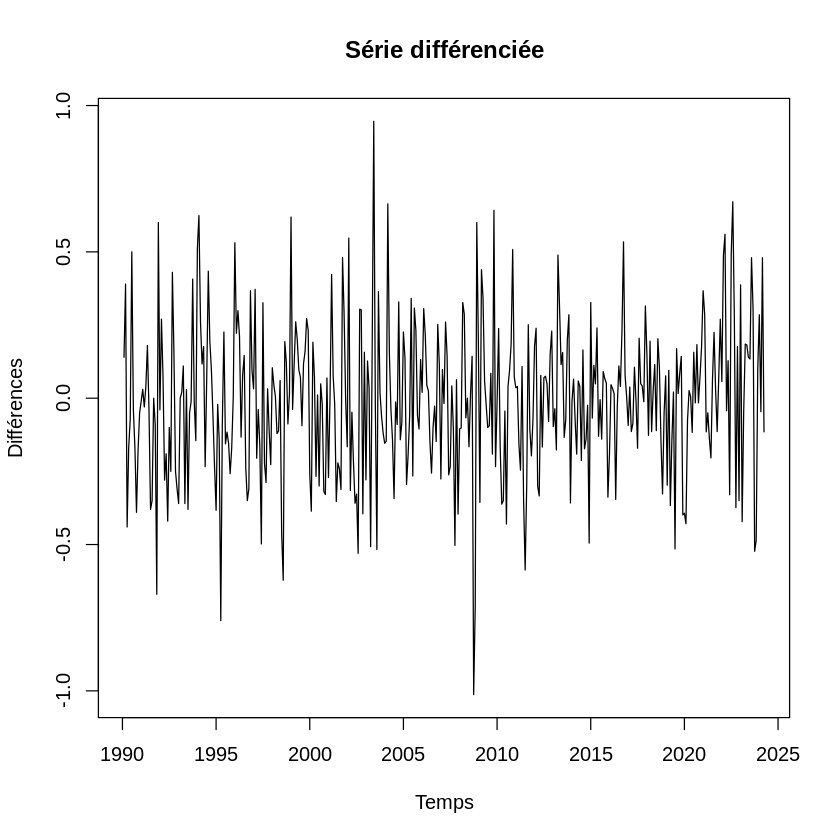

In [ ]:
# Différencier la série
serie_diff <- diff(serie_rate)

# Visualisation de la série différenciée
plot(serie_diff, type = "l", main = "Série différenciée", ylab = "Différences", xlab = "Temps")

# Vérifier la stationnarité de la série différenciée
adf_test_diff <- ur.df(y = serie_diff, type = "none", selectlags = "AIC")
summary(adf_test_diff)


### Analyse des résultats du test Augmented Dickey-Fuller (ADF) sans constante ni tendance

#### Résultats principaux
Statistique Dickey-Fuller : -15.0801
Valeurs critiques (tau1) : -2.58 (1 %), -1.95 (5 %), -1.62 (10 %)
P-value : La statistique est bien inférieure aux seuils critiques pour tous les niveaux de signification (1 %, 5 %, 10 %), ce qui signifie que nous rejetons l'hypothèse nulle (H₀).

#### Analyse des coefficients
1. **Coefficient de z.lag.1 (retard de la série)** :
   - Estimate : -0.99570
   - p-value : < 2e-16
   - Très significatif, ce qui confirme que la présence d'une racine unitaire est rejetée.
2. **z.diff.lag (différence retardée)** :
   - Estimate : 0.10482
   - p-value : 0.0344
   - Significatif au seuil de 5 %, ce qui indique que les retards des différences jouent un rôle dans la dynamique de la série.

##### Conclusion
La série est clairement stationnaire selon ce test ADF sans constante ni tendance. La statistique de test (-15.0801) est bien inférieure aux seuils critiques pour tous les niveaux de signification. Cela indique que l'hypothèse nulle de non-stationnarité (présence d'une racine unitaire) est rejetée. La série différenciée est donc stationnaire.


#### 4) Test KPSS sur les taux différenciés

In [ ]:
# Charger la bibliothèque nécessaire
library(tseries)

# Effectuer un test KPSS pour la stationnarité au niveau
kpss_diff_level <- kpss.test(serie_diff, null = "Level", lshort = TRUE)
print("Résultats du test KPSS pour la stationnarité au niveau :")
print(kpss_diff_level)

# Effectuer un test KPSS pour la stationnarité avec tendance
kpss_diff_trend <- kpss.test(serie_diff, null = "Trend", lshort = TRUE)
print("Résultats du test KPSS pour la stationnarité avec tendance :")
print(kpss_diff_trend)


Warning message in kpss.test(serie_diff, null = "Level", lshort = TRUE):
“p-value greater than printed p-value”


[1] "Résultats du test KPSS pour la stationnarité au niveau :"

	KPSS Test for Level Stationarity

data:  serie_diff
KPSS Level = 0.22656, Truncation lag parameter = 5, p-value = 0.1



Warning message in kpss.test(serie_diff, null = "Trend", lshort = TRUE):
“p-value greater than printed p-value”


[1] "Résultats du test KPSS pour la stationnarité avec tendance :"

	KPSS Test for Trend Stationarity

data:  serie_diff
KPSS Trend = 0.042536, Truncation lag parameter = 5, p-value = 0.1



### Analyse des résultats du test KPSS pour la série différenciée (serie_diff)

### Résultats pour la stationnarité au niveau
Statistique KPSS (niveau) : 0.22656
P-value : >= 0.1
Conclusion : La p-value est supérieure au seuil de 5 %, ce qui signifie que nous ne rejetons pas l'hypothèse nulle de stationnarité au niveau. Cela indique que la série différenciée est stationnaire autour d'une constante.

### Résultats pour la stationnarité avec tendance
Statistique KPSS (tendance) : 0.042536
P-value : >= 0.1
Conclusion : La p-value est également supérieure au seuil de 5 %, ce qui signifie que nous ne rejetons pas l'hypothèse nulle de stationnarité autour d'une tendance linéaire. Cela indique que la série différenciée est également stationnaire avec une tendance.

### Conclusion générale
Les tests KPSS et ADF montrent que la série différenciée des taux  (`serie_diff`) est stationnaire, à la fois au niveau et avec une tendance. Cela valide l'application de la différenciation pour éliminer la non-stationnarité.


### C) Conclusion Globale

Ainsi avec l'ensemble des tests ADF et KPSS, nous pouvons affirmer que nos 2 séries sont bien stationnaires après différenciation et detrend. Désormais nous allons modéliser un ARMA pour la suite de notre projet sur la série des taux


#### IV) Modèle AR, MA ou ARMA sur les taux ?





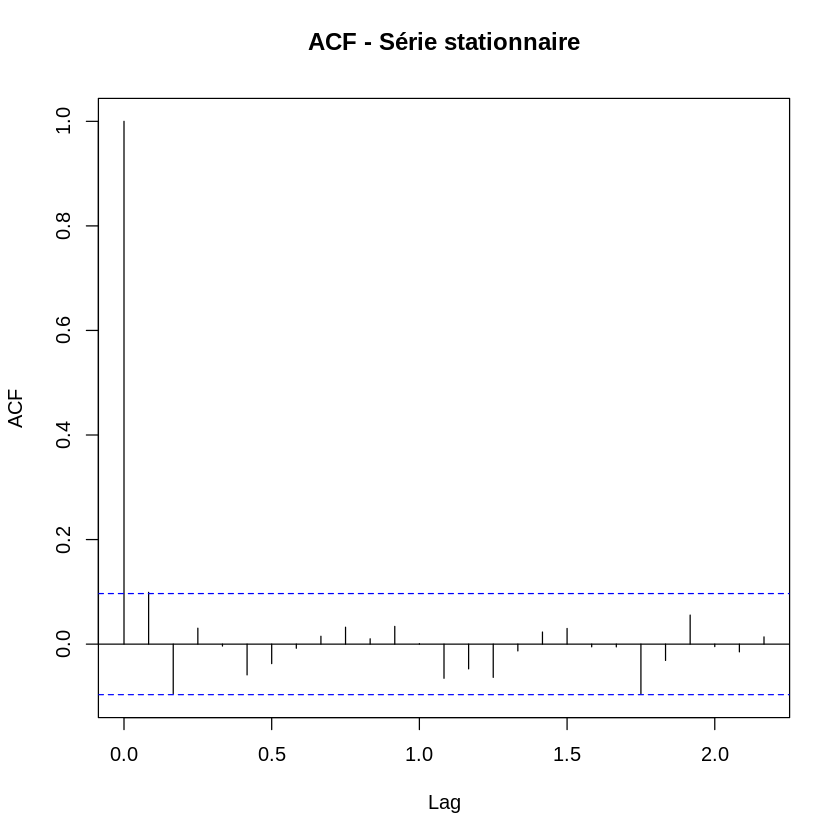

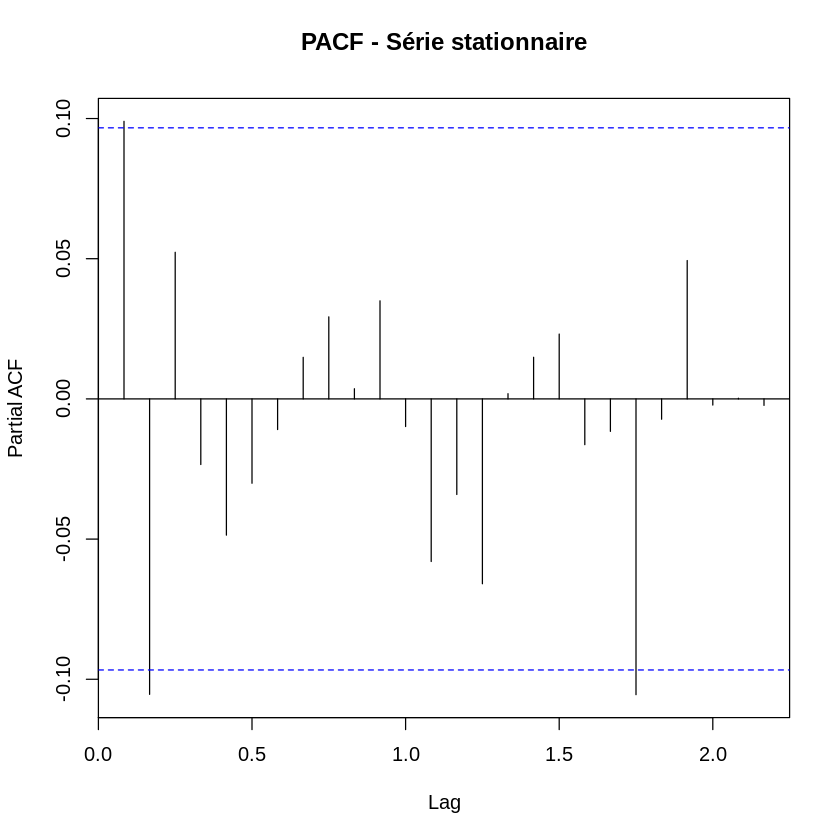

In [ ]:
  acf(serie_diff, main = "ACF - Série stationnaire")   # ACF
  pacf(serie_diff, main = "PACF - Série stationnaire") # PACF

#### Analyse de l'ACF et du PACF
Avec l'ACF et le PACF de la série différencié couplé à ceux de départ, nous supposons qu'un AR(1) est le modèle le plus adapté à notre série temporelle.

#### Recherche du modèle optimal pour notre série sur les taux

In [ ]:
# Fonction pour comparer les modèles AR(p) jusqu'à un ordre maximum spécifié
compare_ar_models <- function(series, max_order = 20) {
  results <- data.frame(Order = integer(), AIC = numeric(), BIC = numeric())

  for (p in 1:max_order) {
    tryCatch({
      # Ajuster un modèle AR(p)
      model <- arima(series, order = c(p, 0, 0))
      # Ajouter les résultats (p, AIC, BIC) au tableau
      results <- rbind(results, data.frame(Order = p, AIC = model$aic, BIC = BIC(model)))
    }, error = function(e) {})
  }

  # Trier les résultats par AIC
  results <- results[order(results$AIC), ]
  return(results)
}

# Assurez-vous que 'serie_diff' est une série temporelle (ts)
ar_model_comparison <- compare_ar_models(serie_diff, max_order = 20)

# Afficher les meilleurs modèles AR par AIC et BIC
print("Comparaison des modèles AR par AIC et BIC :")
print(head(ar_model_comparison))


[1] "Comparaison des modèles AR par AIC et BIC :"
  Order      AIC       BIC
2     2 64.65143  80.72580
3     3 65.47848  85.57144
4     4 67.22927  91.34083
1     1 67.28907  79.34485
5     5 68.26704  96.39719
6     6 69.89863 102.04738


Le critère d'AIC et de BIC vont dans le sens de notre analyse de l'ACF et du PACF et nous propose un AR(2) comme étant le meilleur modèle pour notre série temporelle différencié. Nous allons tout de même rester sur notre intuition de base en modélisant un AR(1°).


Call:
arima(x = serie_diff, order = c(1, 0, 0))

Coefficients:
         ar1  intercept
      0.0989    -0.0096
s.e.  0.0490     0.0143

sigma^2 estimated as 0.06796:  log likelihood = -30.64,  aic = 67.29

Training set error measures:
                        ME      RMSE       MAE MPE MAPE      MASE       ACF1
Training set -3.792976e-05 0.2606988 0.2009588 Inf  Inf 0.7437208 0.01058666


	Box-Ljung test

data:  best_model$residuals
X-squared = 12.675, df = 20, p-value = 0.8909


[1] "Résultats du test de Jarque-Bera :"

	Jarque Bera Test

data:  best_model$residuals
X-squared = 8.0943, df = 2, p-value = 0.01747



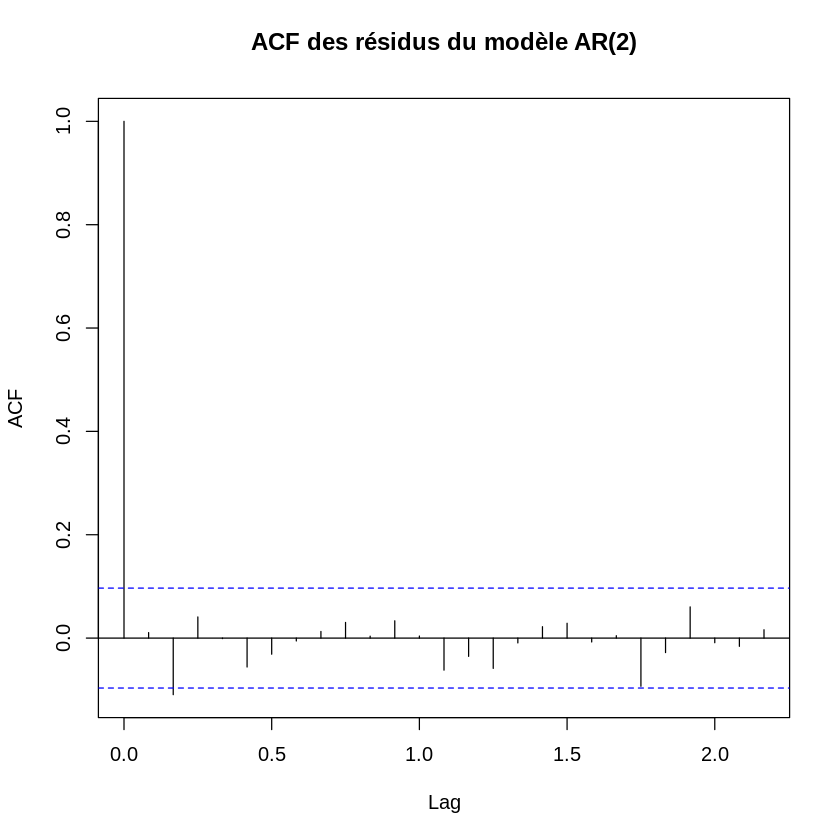

In [ ]:
# Ajustement d'un modèle MA(2) sur la série 'serie_diff'
best_model <- arima(serie_diff, order = c(1, 0, 0))

# Résumé du modèle ajusté
summary(best_model)

# Test de Ljung-Box pour vérifier l'absence d'autocorrélation résiduelle
Box.test(best_model$residuals, lag = 20, type = "Ljung-Box")

# ACF des résidus pour visualiser l'autocorrélation restante
acf(best_model$residuals, main = "ACF des résidus du modèle AR(1)")

# Test de Jarque-Bera pour vérifier la normalité des résidus
library(tseries)
jarque_bera_test <- jarque.bera.test(best_model$residuals)
print("Résultats du test de Jarque-Bera :")
print(jarque_bera_test)


### Analyse du modèle AR(1)

### 1. Résumé des coefficients estimés

- **AR1 : 0.0989**  
  - Ce coefficient capture l'influence de la valeur de la série à une période passée sur la valeur actuelle.  
  - Le ratio estimate/s.e. est de 2.02, ce qui indique que ce coefficient est significatif (\( p < 0.05 \)).  
  - Le signe positif suggère une relation directe (faible) entre les valeurs successives.

- **Intercept : -0.0096**  
  - Ce coefficient n'est pas significatif (\( |\text{Estimate/s.e.}| = 0.67 \)), ce qui signifie qu'il n'apporte pas de contribution statistiquement notable au modèle.

---

### 2. Mesures d'erreur

- **ME (Mean Error)** : -3.793e-05  
  - L'erreur moyenne est proche de zéro, ce qui indique une absence de biais significatif dans les prévisions.

- **RMSE (Root Mean Square Error)** : 0.2607  
  - Une erreur quadratique moyenne raisonnable, indiquant un bon ajustement global.

- **MAE (Mean Absolute Error)** : 0.20096  
  - L'erreur absolue moyenne est faible, montrant une bonne précision.

- **MASE (Mean Absolute Scaled Error)** : 0.74372  
  - Une valeur inférieure à 1, suggérant que le modèle est meilleur qu’un benchmark naïf.

- **ACF1 des résidus** : 0.01059  
  - L’autocorrélation au premier lag est proche de zéro, ce qui est une bonne indication de l’absence de corrélation résiduelle.

---

### 3. Résidus et diagnostics

### Box-Ljung Test
- **Statistique du test** : 12.675  
- **p-value** : 0.8909  
  - La p-value élevée (\( p > 0.05 \)) indique qu’il n’y a **pas d’autocorrélation significative** dans les résidus. Cela valide l’ajustement du modèle.

### Jarque-Bera Test
- **Statistique du test** : 8.0943  
- **p-value** : 0.01747  
  - La p-value (\( p < 0.05 \)) indique que les résidus **ne suivent pas strictement une distribution normale**. Cela pourrait affecter légèrement la fiabilité des intervalles de confiance.

---

### 4. Critères d'information

- **Log-likelihood** : -30.64  
  - Mesure de la vraisemblance du modèle ajusté.

- **AIC (Akaike Information Criterion)** : 67.29  
  - L'AIC est légèrement plus élevé que celui des modèles AR(2) ou MA(2), indiquant qu’AR(1) est peut-être moins performant.

---

### 5. Conclusion

- Le modèle AR(1) est simple et **significatif**, avec un coefficient AR1 qui capture une faible relation directe entre les observations consécutives.
- Les résidus ne présentent **pas d’autocorrélation significative** (test de Box-Ljung), validant le modèle en termes de structure temporelle.
- Cependant, les résidus présentent une légère **déviation de la normalité** (p-value Jarque-Bera \( < 0.05 \)).



### Test de présence de l'effet ARCH

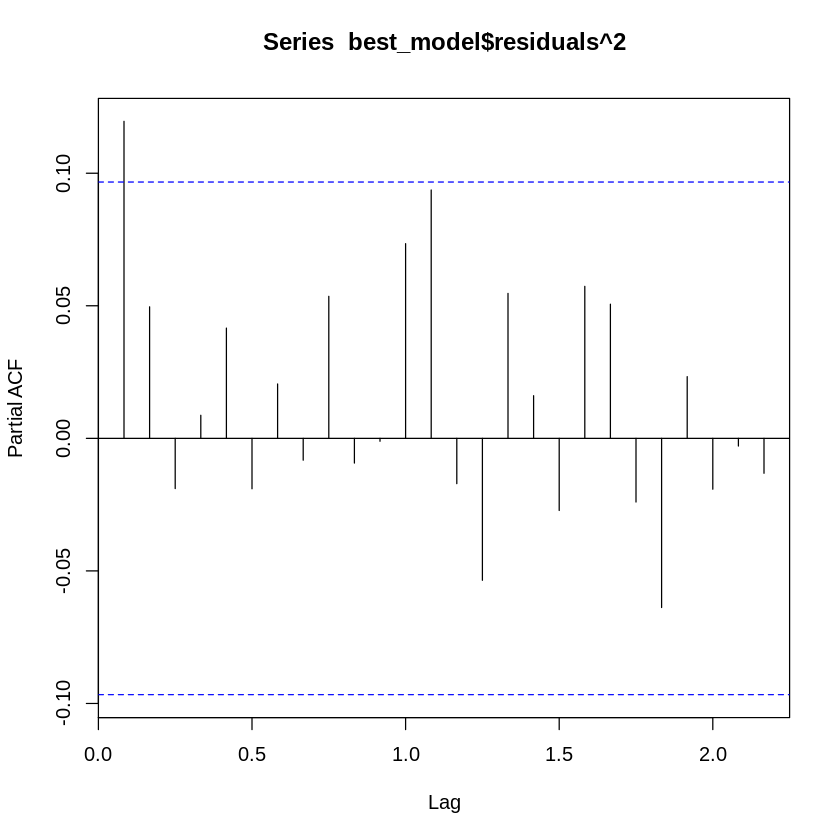

In [ ]:
pacf(best_model$residuals^2)

On utilise la fonction ArchTest de la library FinTS (il existe d'autres fonctions dans les packages ATSA et NortsTest notamment)

On teste l'hypothèse d'absence d'effet ARCH avec deux retards. La régression estimée est :

$$
\hat{\epsilon}_{t}^{2}= \gamma_{0} + \gamma_{1} \hat{\epsilon}_{t-1}^{2} +\gamma_{2} \hat{\epsilon}_{t-2}^{2}
$$


Les hypothèses du test sont :

$$
\left\{
\begin{array}{ll}
H_{0} : \gamma_{1}=\gamma_{2}=0 \Rightarrow \,pas\,d'effet\,ARCH\\
H_{a} : \gamma_{1}\neq 0\, ou \,... \gamma_{2} \neq 0 \Rightarrow effet\,ARCH
\end{array}
\right.
$$

In [ ]:
# Installer le package FinTS
install.packages("FinTS")

# Charger le package
library(FinTS)

ArchTest(best_model$residuals,lags=1,demean = FALSE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




	ARCH LM-test; Null hypothesis: no ARCH effects

data:  best_model$residuals
Chi-squared = 5.8661, df = 1, p-value = 0.01544


### Analyse du test ARCH LM

#### Résultats du test
- **Statistique du test** : 5.8661  
- **Degrés de liberté (df)** : 1  
- **p-value** : 0.01544  

---

#### Interprétation des hypothèses

- **Hypothèse nulle (H0)** : Il n'y a pas d'effets ARCH dans les résidus (les variances conditionnelles sont constantes, homogènes dans le temps).  
- **Hypothèse alternative (H1)** : Il existe des effets ARCH dans les résidus (les variances conditionnelles changent avec le temps).  

La p-value obtenue est **0.01544**, ce qui est inférieure à 0.05. Cela signifie que nous **rejetons l'hypothèse nulle** au niveau de signification de 5 %.  

---

#### Conclusion

- La présence d'effets ARCH est détectée dans les résidus, indiquant que la variance des résidus n'est pas constante dans le temps.  
- Cela suggère que notre modèle actuel (probablement ARIMA ou AR) ne capture pas correctement la dynamique des variances conditionnelles.

On peut donc construire un modèle GARCH(1,1)



In [ ]:
# Installer et charger les packages nécessaires
install.packages("rugarch")
library(rugarch)

# Spécification du modèle AR(1)-GARCH(1,1)
spec_garch <- ugarchspec(
  variance.model = list(model = "sGARCH", garchOrder = c(1, 1)),
  mean.model = list(armaOrder = c(1, 0), include.mean = TRUE),
  distribution.model = "norm"  # Distribution normale pour les résidus
)

# Ajustement du modèle GARCH
fit_garch <- ugarchfit(spec = spec_garch, data = best_model$residuals)

# Résumé des résultats
print(fit_garch)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(1,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000749    0.012713  0.058918 0.953018
ar1     0.015713    0.050314  0.312299 0.754813
omega   0.004535    0.003664  1.237818 0.215784
alpha1  0.040374    0.021877  1.845520 0.064962
beta1   0.893029    0.063797 13.997903 0.000000

Robust Standard Errors:
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000749    0.012030  0.062263 0.950354
ar1     0.015713    0.042163  0.372671 0.709394
omega   0.004535    0.003413  1.328855 0.183896
alpha1  0.040374    0.016456  2.453495 0.014148
beta1   0.893029    0.051926 17.198107 0.000000

LogLikelihood : -27.68414 

Information Criteria
------------------------------------
   

#### Conclusion
- Le modèle **AR(1)-GARCH(1,1)** est bien ajusté et capture efficacement la volatilité conditionnelle grâce aux coefficients significatifs de **alpha1** et **beta1**.  
- Les résidus ne présentent pas d’autocorrélation ni d’effets ARCH résiduels.  
- Ce modèle est robuste et stable, et peut être utilisé pour des prévisions de volatilité.

### V) Prévisions avec notre AR(1)

In [ ]:
# Extraire et afficher les 3 dernières valeurs de la série
last_three_values <- tail(serie_rate, n = 3)

# Affichage des 3 dernières valeurs
cat("Les 3 dernières valeurs de la série sont :", last_three_values, "\n")


Les 3 dernières valeurs de la série sont : 4.206 4.686 4.571 


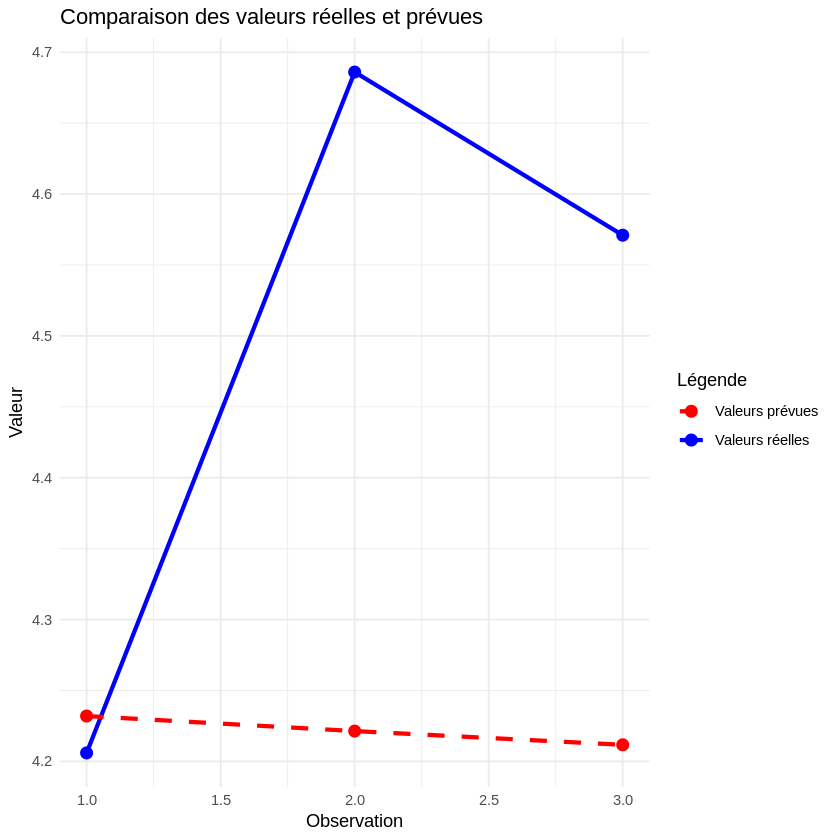

In [ ]:
# Charger les bibliothèques nécessaires
library(forecast)
library(ggplot2)

# Supprimer les 3 dernières valeurs de la série
serie_truncated <- head(serie_rate, -3)

# Les 3 dernières valeurs réelles pour la comparaison
last_three_values <- tail(serie_rate, n = 3)

# Effectuer des prévisions (3 étapes en avant) à partir du modèle best_model
forecast_values <- predict(best_model, n.ahead = 3)

# Prévisions différenciées
predicted_diff <- forecast_values$pred  # Prévisions différenciées

# Dernière valeur de la série tronquée
last_value <- tail(serie_truncated, n = 1)

# Reconstitution des prévisions en échelle originale
predicted_original <- cumsum(c(last_value, as.numeric(predicted_diff)))[-1]

# Créer un data frame pour la comparaison
comparison_df <- data.frame(
  Date = 1:3,
  Réelles = as.numeric(last_three_values),
  Prévues = predicted_original
)

# Visualisation avec ggplot2
ggplot(comparison_df, aes(x = Date)) +
  geom_line(aes(y = Réelles, color = "Valeurs réelles"), size = 1.2) +
  geom_line(aes(y = Prévues, color = "Valeurs prévues"), size = 1.2, linetype = "dashed") +
  geom_point(aes(y = Réelles, color = "Valeurs réelles"), size = 3) +
  geom_point(aes(y = Prévues, color = "Valeurs prévues"), size = 3) +
  labs(
    title = "Comparaison des valeurs réelles et prévues",
    x = "Observation",
    y = "Valeur",
    color = "Légende"
  ) +
  theme_minimal() +
  scale_color_manual(values = c("Valeurs réelles" = "blue", "Valeurs prévues" = "red"))




Le modèle à tendance à lisser les prévisions. Dans la réalité, les taux d'intérêts sont certes des valeurs économiques mais ce sont des données influencées par la politique monétaire de la FED.

In [ ]:
# Calcul des métriques d'erreur : RMSE et MAE
rmse <- sqrt(mean((comparison_df$Réelles - comparison_df$Prévues)^2))  # Calcul du RMSE
mae <- mean(abs(comparison_df$Réelles - comparison_df$Prévues))        # Calcul du MAE

# Résumé des métriques
cat("Analyse des erreurs :\n")
cat("RMSE (Root Mean Squared Error) :", rmse, "\n")
cat("MAE (Mean Absolute Error) :", mae, "\n")



Analyse des erreurs :
RMSE (Root Mean Squared Error) : 0.3394148 
MAE (Mean Absolute Error) : 0.2832923 


### Analyse des erreurs

### Résultats des métriques
- **RMSE (Root Mean Squared Error)** : 0.3394148  
  Le RMSE mesure la racine carrée de la moyenne des carrés des erreurs. Une valeur relativement faible indique que les erreurs de prédiction sont petites en moyenne, ce qui est un signe positif de la performance du modèle.

- **MAE (Mean Absolute Error)** : 0.2832923  
  Le MAE calcule la moyenne des erreurs absolues entre les valeurs observées et prédites. Cette métrique est intuitive et permet de quantifier l'erreur moyenne sans pénaliser de manière excessive les grandes erreurs.

---

### Interprétation des métriques
- Le **MAE** est toujours inférieur ou égal au **RMSE**, car le RMSE pénalise davantage les grandes erreurs. Ici, la différence est faible, ce qui indique que les grandes erreurs ne dominent pas les prédictions.  
- Ces valeurs montrent que le modèle offre un ajustement raisonnable, avec des erreurs relativement faibles dans les prédictions.

---

### Conclusion
Le modèle présente des erreurs relativement faibles avec un **RMSE de 0.3394** et un **MAE de 0.2833**, indiquant une bonne performance globale. Ces métriques montrent que les prévisions du modèle sont proches des valeurs observées en moyenne. Si nécessaire, explorez d'autres options pour réduire davantage ces erreurs.


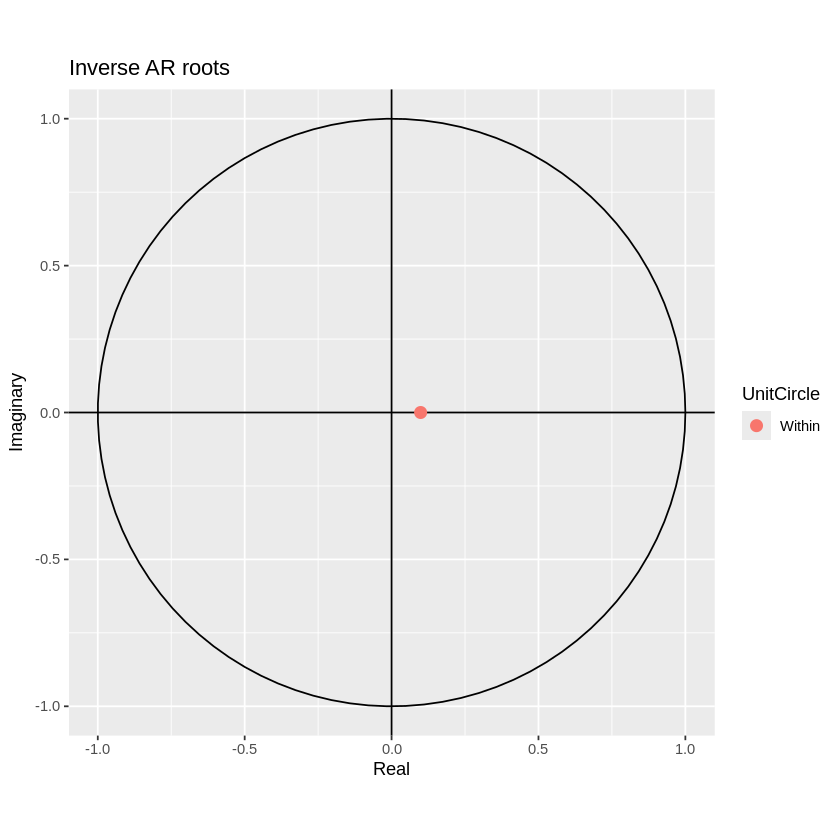

In [ ]:
autoplot(best_model)

### Conclusion de la partie

Ainsi, ce modèle que nous avons estimer par les ACF et PACF de notre série origial, complété des ACF et PACF des séries différencier nous donne un modèle plutôt robuste économétriquement mais qui a dû mal a bien expliquer l'intégralité de notre modèle et possède un effet ARCH. Nous pourrons faire des prévisions avce le modèle GARCH(1,1) pour d emeilleur prévisions si on le souhaitait.

###Partie 2 : Modélisaiton Multivariée


### VI) Modèle VAR

### Taux de croissance du taux d'intêret 10Y américain et du cours de l'or

On calcule les taux de croissance comme la différence première de variables en logarithme.





Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


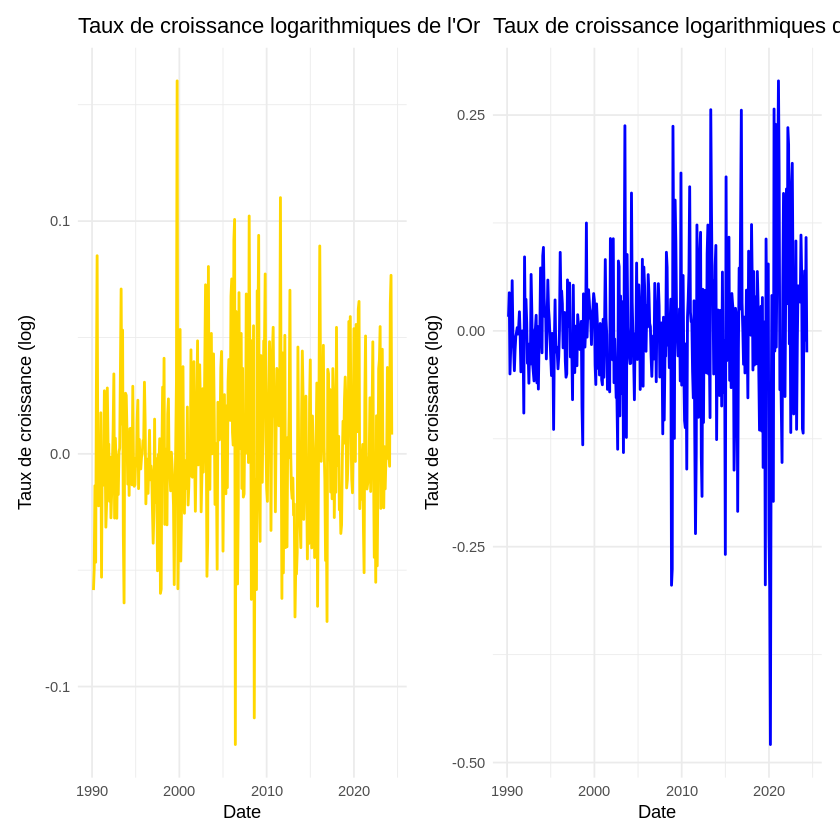

In [ ]:
library(ggplot2)
library(dplyr)
install.packages("patchwork")
library(patchwork)  # Pour combiner les graphiques côte à côte

# Calculer les logarithmes des séries
data_gold <- data_gold %>%
  mutate(Log_Gold = log(Gold))

data_rate <- data_rate %>%
  mutate(Log_Rate = log(Rate))

# Calculer les taux de croissance (différences premières des logarithmes)
data_gold <- data_gold %>%
  mutate(Gold_Growth = c(NA, diff(Log_Gold)))

data_rate <- data_rate %>%
  mutate(Rate_Growth = c(NA, diff(Log_Rate)))

# Graphique pour les taux de croissance de l'or
plot_gold <- ggplot(data_gold, aes(x = Date, y = Gold_Growth)) +
  geom_line(color = "gold", size = 0.8) +
  labs(
    title = "Taux de croissance logarithmiques de l'Or",
    x = "Date",
    y = "Taux de croissance (log)"
  ) +
  theme_minimal()

# Graphique pour les taux de croissance des taux US 10Y
plot_rate <- ggplot(data_rate, aes(x = Date, y = Rate_Growth)) +
  geom_line(color = "blue", size = 0.8) +
  labs(
    title = "Taux de croissance logarithmiques des Taux US 10Y",
    x = "Date",
    y = "Taux de croissance (log)"
  ) +
  theme_minimal()

# Combiner les deux graphiques côte à côte
combined_plot <- plot_gold + plot_rate

# Afficher les graphiques combinés
print(combined_plot)


In [ ]:
data_combined <- merge(data_gold, data_rate, by = "Date", all = TRUE)


cat("Résumé statistique des taux de croissance logarithmiques :\n")
summary(data_combined[c("Gold_Growth", "Rate_Growth")])
cat("\nÉcarts-types des taux de croissance logarithmiques :\n")
sapply(data_combined[c("Gold_Growth", "Rate_Growth")], sd)

Résumé statistique des taux de croissance logarithmiques :


  Gold_Growth          Rate_Growth       
 Min.   :-0.1248967   Min.   :-0.479095  
 1st Qu.:-0.0161959   1st Qu.:-0.044632  
 Median : 0.0001503   Median :-0.001392  
 Mean   : 0.0042075   Mean   :-0.001512  
 3rd Qu.: 0.0247760   3rd Qu.: 0.039935  
 Max.   : 0.1602307   Max.   : 0.289510  
 NA's   :1            NA's   :1          


Écarts-types des taux de croissance logarithmiques :


Gold_Growth Rate_Growth 
         NA          NA

#### Analyse des résultats des statistiques descriptives

#### Résumé des taux de croissance logarithmiques pour Gold_Growth
1. **Gold_Growth :**
   - **Min :** -0.1249
     - La plus forte baisse des taux de croissance de l'or a été d'environ -12.49 %, indiquant une forte chute à une observation donnée.
   - **1er Quartile :** -0.0162
     - 25 % des valeurs sont en dessous de -1.62 %, montrant des baisses fréquentes, mais modérées.
   - **Médiane :** 0.00015
     - La médiane est très proche de zéro, ce qui suggère que la majorité des variations sont faibles ou proches de la stabilité.
   - **Moyenne :** 0.0042
     - La moyenne positive (environ 0.42 %) montre une légère tendance haussière des taux de croissance sur la période étudiée.
   - **3e Quartile :** 0.0248
     - 25 % des valeurs les plus élevées dépassent une hausse de 2.48 %, indiquant quelques augmentations significatives.
   - **Max :** 0.1602
     - La plus forte hausse a été de 16.02 %, soulignant une observation particulièrement marquée.

---

#### Résumé des taux de croissance logarithmiques pour Rate_Growth
2. **Rate_Growth :**
   - **Min :** -0.4791
     - La plus forte baisse des taux de croissance des taux US 10Y a été de -47.91 %, reflétant une chute extrême pour une observation donnée.
   - **1er Quartile :** -0.0446
     - 25 % des valeurs sont inférieures à -4.46 %, montrant des baisses fréquentes, mais généralement moins prononcées que le minimum.
   - **Médiane :** -0.00139
     - Une médiane légèrement négative (-0.14 %) indique une tendance globale légèrement baissière.
   - **Moyenne :** -0.0015
     - La moyenne négative (environ -0.15 %) corrobore une faible tendance baissière des taux.
   - **3e Quartile :** 0.0399
     - 25 % des valeurs les plus élevées dépassent une hausse de 3.99 %, signalant des augmentations modérées.
   - **Max :** 0.2895
     - La plus forte hausse a été de 28.95 %, indiquant un événement marquant ou une variation exceptionnelle.

---

#### Observation globale
- **Gold_Growth** présente une moyenne légèrement positive (croissance légère sur la période), alors que **Rate_Growth** a une moyenne légèrement négative (faible baisse globale).
- Les variations extrêmes sont beaucoup plus marquées pour **Rate_Growth** que pour **Gold_Growth**, avec un minimum de -47.91 % et un maximum de 28.95 %.
(Sans doute dû au politique monétaire radicale au cours des dernières 30 années)


### Mise en place du modèle VAR

Pour ce modèle, nous allons utiliser nos séries stationnarisées afin de sastifaire les conditions pour utiliser ce type de modèle multivarié

In [ ]:
# Installation et chargement des packages nécessaires
if (!require(vars)) install.packages("vars")
library(vars)

# Création du dataset pour le modèle VAR
data_var <- data.frame(rate = serie_diff, gold = serie_gold_diff)

# Détermination du nombre optimal de retards (lags) pour le modèle VAR
var_select <- VARselect(data_var, lag.max = 10, type = "const")
print(var_select)



Loading required package: vars

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘vars’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘strucchange’, ‘sandwich’


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:patchwork’:

    area


The following object is masked from ‘package:dplyr’:

    select


Loading required package: strucchange

Loading required package: sandwich

Loading required package: lmtest



$selection
AIC(n)  HQ(n)  SC(n) FPE(n) 
     1      1      1      1 

$criteria
               1         2         3        4         5         6         7
AIC(n)  4.489918  4.493625  4.506680  4.52222  4.524951  4.533025  4.540511
HQ(n)   4.513581  4.533065  4.561894  4.59321  4.611717  4.635566  4.658828
SC(n)   4.549678  4.593226  4.646120  4.70150  4.744071  4.791985  4.839311
FPE(n) 89.114160 89.445372 90.621060 92.04105 92.293931 93.043793 93.745204
               8         9        10
AIC(n)  4.543296  4.558533  4.570431
HQ(n)   4.677389  4.708402  4.736075
SC(n)   4.881936  4.937013  4.988751
FPE(n) 94.009695 95.456944 96.604283



#### Analyse des critères de sélection du modèle VAR

### 1. Sélection des lags optimaux
Tous les critères (AIC, HQ, SC, FPE) indiquent que **1 lag** est optimal pour le modèle VAR. Cela signifie qu'un décalage temporel (lag = 1) est suffisant pour capturer la dynamique des séries temporelles.

- **Tous les critères (AIC, HQ, SC, FPE) recommandent un modèle VAR avec \( p = 1 \) lag.**
- Des lags supplémentaires augmentent systématiquement les pénalités sans apporter d'amélioration significative.


In [ ]:
# Estimation du modèle VAR avec la composante déterministe choisie
var_model <- VAR(data_var, p = 1, type="const")

# Affichage du summary du modèle
summary(var_model)


VAR Estimation Results:
Endogenous variables: rate, gold 
Deterministic variables: const 
Sample size: 410 
Log Likelihood: -2076.061 
Roots of the characteristic polynomial:
0.2103 0.09761
Call:
VAR(y = data_var, p = 1, type = "const")


Estimation results for equation rate: 
rate = rate.l1 + gold.l1 + const 

          Estimate Std. Error t value Pr(>|t|)  
rate.l1  9.885e-02  4.976e-02   1.987   0.0476 *
gold.l1 -1.027e-05  3.539e-04  -0.029   0.9769  
const   -9.024e-03  1.294e-02  -0.697   0.4860  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Residual standard error: 0.2619 on 407 degrees of freedom
Multiple R-Squared: 0.009816,	Adjusted R-squared: 0.00495 
F-statistic: 2.017 on 2 and 407 DF,  p-value: 0.1343 


Estimation results for equation gold: 
gold = rate.l1 + gold.l1 + const 

         Estimate Std. Error t value Pr(>|t|)    
rate.l1 -13.47539    6.82149  -1.975   0.0489 *  
gold.l1   0.20903    0.04851   4.309 2.06e-05 ***
const     0.18937    1.7

In [ ]:
A<-Acoef(var_model)
A

,rate.l1,gold.l1
rate,0.09885161,-0.0000102733
gold,-13.47539461,0.2090277416


### Analyse des résultats du modèle VAR

#### Équation du taux de croissance de l'or (gold)
Équation du taux de croissance de l'or (gold) :
L'équation estimée est : gold_t = 0.209 * gold_t-1 - 13.475 * rate_t-1 + 0.189

1. Effet de gold.l1 (retard de gold) :
- Le coefficient est positif et significatif pour un risque de première espèce de 1% (p < 0.001).
- Interprétation : Une valeur passée de gold tend à influencer positivement sa valeur présente, indiquant une persistance dans l'évolution trimestrielle du taux de croissance de l'or.

2. Effet de rate.l1 (retard de rate) :
- Le coefficient est négatif et significatif pour un risque de première espèce de 5% (p = 0.0489).
- Interprétation : Une hausse des taux d’intérêt à une période donnée entraîne une baisse significative du taux de croissance de l’or, reflétant une relation inverse entre les deux variables.

#### Équation du taux de croissance des taux (rate)
Équation du taux de croissance des taux (rate) :
L'équation estimée est : rate_t = -0.00001 * gold_t-1 + 0.09885 * rate_t-1 - 0.009

1. Effet de gold.l1 (retard de gold) :
- Le coefficient est non significatif (p = 0.977).
- Interprétation : L'évolution passée de gold n’a pas d’effet significatif sur les taux d’intérêt.

2. Effet de rate.l1 (retard de rate) :
- Le coefficient est positif et significatif pour un risque de première espèce de 5% (p = 0.0476).
- Interprétation : Le taux de croissance des taux est corrélé positivement à sa valeur passée, reflétant une persistance dans l'évolution des taux d’intérêt.

4. Qualité de la régression :
- R² ajusté : 0.5%.
- Interprétation : Le modèle capture peu de variabilité des taux, ce qui indique que d'autres facteurs explicatifs pourraient être nécessaires.

Ainsi, bien que ce modèle VAR capture quelques dynamiques clés, il reste limité dans son pouvoir explicatif et pourrait être amélioré avec des analyses supplémentaires et un enrichissement des données comme l'ajout d'autres variables explicatives afin d'enrichir le modèle.


### VII) Analyse des relations de causalité

#### Test de Granger et causalité

On vérifie la significativité du coefficient de $\_rate_{t-1}$ dans l'équation de $\_gold_{t}$. Les hypothèses du test sont :

$$
\left\lbrace
\begin{array}{l}
H_{0} : a_{12}^{1}=0\Rightarrow\,\text{rate ne cause pas gold}\\
H_{1} : a_{12}^{1}\neq 0 \Rightarrow\,\text{rate cause gold}
\end{array}
\right.
$$

In [ ]:
# Test de causalité de Granger
granger_test_gold_to_rate <- causality(var_model, cause = "gold") # Teste si "gold" cause "rate"
print(granger_test_gold_to_rate)

granger_test_rate_to_gold <- causality(var_model, cause = "rate") # Teste si "rate" cause "gold"
print(granger_test_rate_to_gold)


$Granger

	Granger causality H0: gold do not Granger-cause rate

data:  VAR object var_model
F-Test = 0.0008429, df1 = 1, df2 = 814, p-value = 0.9768


$Instant

	H0: No instantaneous causality between: gold and rate

data:  VAR object var_model
Chi-squared = 6.2599, df = 1, p-value = 0.01235


$Granger

	Granger causality H0: rate do not Granger-cause gold

data:  VAR object var_model
F-Test = 3.9023, df1 = 1, df2 = 814, p-value = 0.04856


$Instant

	H0: No instantaneous causality between: rate and gold

data:  VAR object var_model
Chi-squared = 6.2599, df = 1, p-value = 0.01235




####Résultats pour la stationnarité au niveau

Test 1 : Granger causality (gold → rate)

Statistique F-Test : 0.0008429
P-value : 0.9768
Conclusion : La p-value est bien supérieure au seuil de 5 %, ce qui signifie que nous ne rejetons pas l'hypothèse nulle.

Test 2 : Instantaneous causality (gold ↔ rate)

Statistique Chi-squared : 6.2599
P-value : 0.01235
Conclusion : La p-value est inférieure au seuil de 5 %, ce qui signifie que nous rejetons l'hypothèse nulle.

Test 3 : Granger causality (rate → gold)

Statistique F-Test : 3.9023
P-value : 0.04856
Conclusion : La p-value est légèrement inférieure au seuil de 5 %, ce qui signifie que nous rejetons l'hypothèse nulle.

Test 4 : Instantaneous causality (rate ↔ gold)

Statistique Chi-squared : 6.2599
P-value : 0.01235
Conclusion : La p-value est inférieure au seuil de 5 %, ce qui signifie que nous rejetons l'hypothèse nulle.

####Est ce que le cours de l'or cause les taux ?

La p-value est très élevée (supérieure à 0.05), donc on ne rejette pas l'hypothèse nulle. Cela signifie que les valeurs passées de l'or ne causent pas les taux d'intérêt. D'un point de vue économique, ce résultat est logique.

Causalité instantanée :
La p-value est inférieure à 0.05, ce qui indique qu'il y a une causalité instantanée significative entre l'or et les taux d'intérêt à un instant donné.

####Les taux causent-ils le cours de l'or ?

La p-value est inférieure à 0.05, ce qui permet de rejeter l'hypothèse nulle. Cela indique que les taux d'intérêt passés causent l'or. D'un point de vue économique, ce résultat est également logique car lorsque les investisseurs perdent confiance dans la croissance à long terme, ils se réfugient dans les obligations, ce qui cause une baisse des taux. Et la surveillance des taux à la baisse sert d'indicateur pour acheter des valeurs refuges, ce qui fait grimper le cours de l'or.

Causalité instantanée :

Il y a également une causalité instantanée significative entre les taux d'intérêt et l'or.

### VIII) Analyse impulsion-réponse des chocs sur les di↵érentes variables

#### Impulsion réponse

Comme nous avons vu précédent que les taux passés ont une influence sur le cours de l'or, nous avons étudier l'effet d'un choc des taux sur l'or.

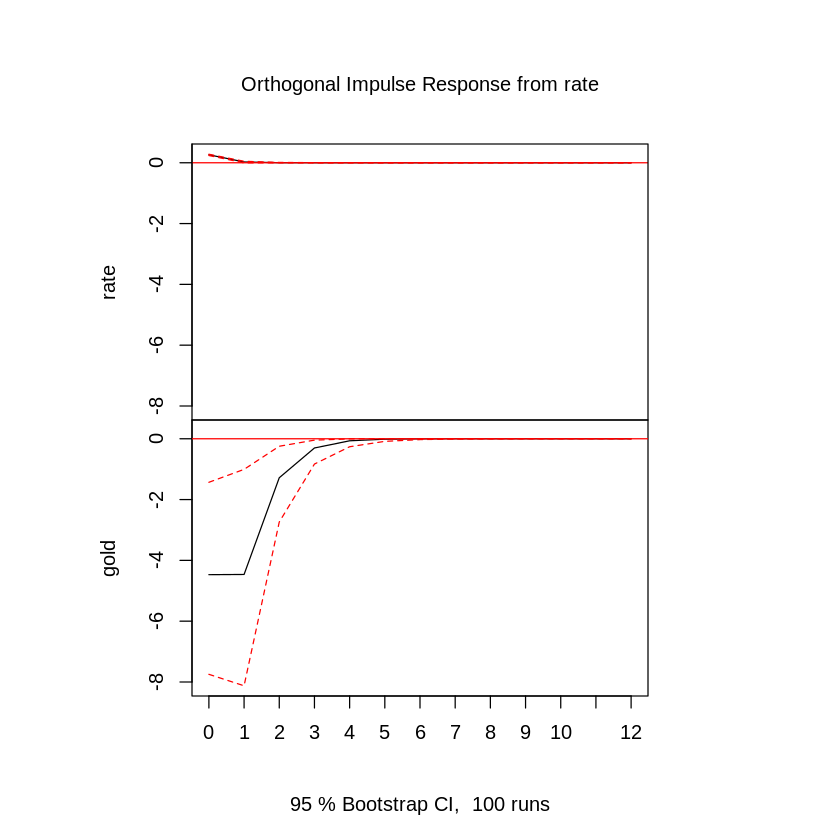

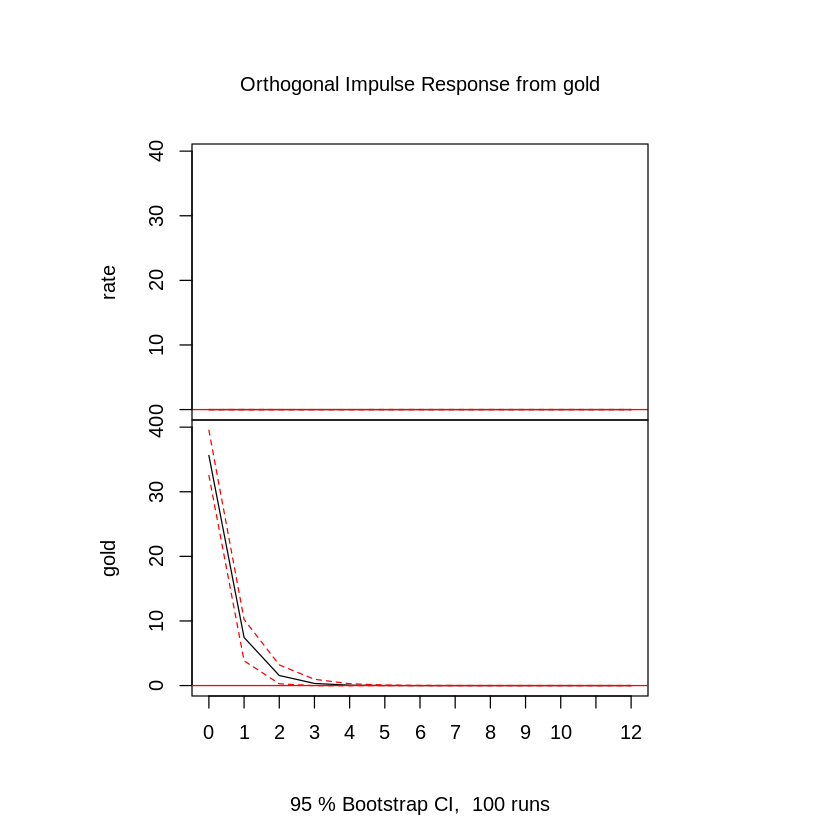

In [ ]:
# Les taux sont déjà en première ligne du VAR, ils sont plus causale au sens de granger que l'or.

# Créer les résultats d'IRF pour toutes les variables
irf_results <- irf(
  var_model,          # Modèle VAR ajusté
  n.ahead = 12,       # Horizon de prévision
  ortho = TRUE,       # Chocs orthogonaux
  ci = 0.95           # Intervalle de confiance à 95%
)

# Tracer les réponses impulsionnelles
plot(irf_results)



### Graphique 1 :
Partie supérieure (Impact sur "rate"). La réponse de "rate" à un choc sur lui-même semble être quasi nulle ou rapidement dissipée.
Cela peut indiquer que le taux d'intérêt est relativement stable ou qu'il est bien expliqué par d'autres variables dans le modèle.

Partie inférieure (Impact sur "gold"). On observe une réaction initialement négative de l'or à un choc sur le taux d'intérêt.
Le prix de l'or diminue progressivement jusqu'à une stabilisation vers la période 4 ou 5. Cette tendance négative est conforme à la théorie économique : des taux d'intérêt plus élevés rendent les actifs financiers plus attractifs par rapport à l'or (qui ne génère pas de rendement).
Les intervalles de confiance (lignes rouges en pointillés) montrent que cette réaction est statistiquement significative dans les premières périodes.

### Graphique 2 :

Partie supérieure (Impact sur "rate"). Les taux d'intérêt ne montrent pas de réponse significative à un choc sur l'or. Cela suggère que l'or n'a pas un effet causal fort sur les taux dans votre modèle. Les intervalles de confiance incluent zéro tout au long des périodes, ce qui confirme cette observation.

Partie inférieure (Impact sur "gold"). L'impact initial d'un choc sur le prix de l'or est très marqué, avec une forte augmentation au début. Cette réponse décroit rapidement et tend vers zéro après environ 5 périodes, montrant une dynamique d'ajustement rapide du marché de l'or. Les intervalles de confiance étroits confirment la robustesse de cette dynamique.

###Méthode des Projections locales

[[1]]
NULL


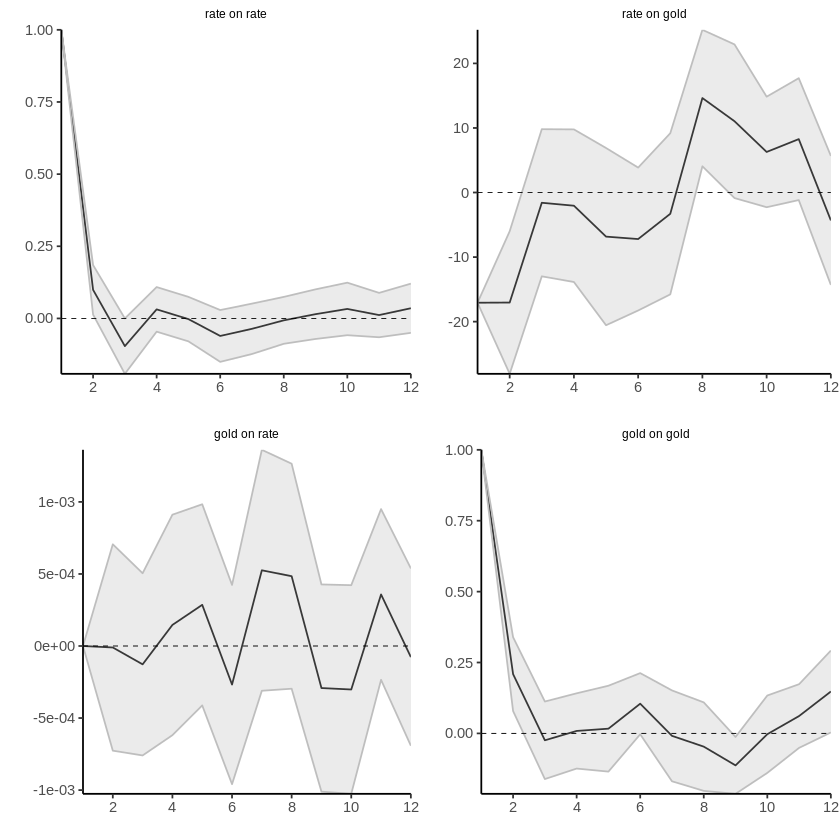

In [ ]:
# Installation et chargement du package lpirfs
if (!require(lpirfs)) install.packages("lpirfs")
library(lpirfs)

# Vérification des données : suppression des valeurs manquantes
data_var_clean <- na.omit(data_var)

# Projections locales pour analyser l'impact des chocs de "rate" sur "gold"
lp_results <- lp_lin(
  endog_data = data_var_clean,       # Données des variables endogènes
  lags_endog_lin = NaN,               # Nombre de retards (lags)
  lags_criterion = 'BIC',           # Critère pour ajuster automatiquement le nombre de lags
  max_lags = 8,                     # Nombre maximal de lags
  trend = 0,                        # Pas de tendance incluse
  shock_type = 1,                   # Choc standardisé
  confint = 1.96,                   # Intervalle de confiance à 95%
  hor = 12,                         # Horizon de prévision (12 périodes)
  adjust_se = TRUE                  # Ajustement des erreurs standard
)

# Visualisation des projections locales
plot(lp_results)


###Interprétation

Rate on rate (en haut à gauche) : Ce graphique montre l'impact d'un choc sur les taux d'intérêts sur eux-mêmes. On peut observer que le taux d'intérêt réagit fortement au choc initial, puis l'effet décroît progressivement au fil du temps. Après quelques périodes, l'impact devient très faible, proche de zéro. Cela suggère que le choc sur les taux d'intérêt a un effet transitoire sur lui-même.

Rate on gold (en haut à droite) : Ce graphique montre l'impact d'un choc sur le taux d'intérêt sur le prix de l'or. On peut voir que le choc sur les taux d'intérêt a un effet négatif sur le prix de l'or, en particulier dans les premières périodes (les valeurs deviennent très négatives). Cela suggère qu'une hausse des taux d'intérêt réduit rapidement la demande d'or ou affecte négativement son prix dans l'immédiat. Cet effet semble se dissiper au fil du temps.

Gold on rate (en bas à gauche) : Ce graphique montre l'impact d'un choc sur le prix de l'or sur le taux d'intérêt. Les résultats indiquent que les chocs sur l'or ont un effet relativement faible et temporaire sur les taux d'intérêt. Le choc initial semble avoir un impact très faible, ce qui suggère que les prix de l'or ne sont pas un facteur majeur déterminant les variations des taux d'intérêt dans l'horizon temporel de l'analyse.

Gold on gold (en bas à droite) : Ce graphique montre l'impact d'un choc sur du prix de l'or sur lui-même. L'impact du choc est important au début, puis l'effet devient plus faible, se stabilisant vers zéro après plusieurs périodes. Cela montre que les prix de l'or réagissent immédiatement à un choc, mais cet effet se dissipe au fur et à mesure que le marché se réajuste.

### IX) Analyse de la cointégration

#### Test de cointégration de Johansen

Le test de cointégration de Johansen est utilisé pour déterminer si plusieurs séries temporelles évoluent à long terme de manière cohérente.

####Test de la trace

Le test de la trace examine l'existence de vecteurs de cointégration. Les hypothèses sont les suivantes :

Hypothèse nulle (H₀) : Le nombre de vecteurs de cointégration est égal à
𝑟.
Hypothèse alternative (H₁) : Le nombre de vecteurs de cointégration est supérieur à
𝑟.

Le test trace l'évolution de la statistique de test pour différents nombres de vecteurs de cointégration, et la décision se fait en comparant la statistique obtenue avec les valeurs critiques.

Règle de décision :

Si la statistique de test est supérieure à la valeur critique pour un certain nombre de vecteurs de cointégration, on rejette l'hypothèse nulle et on conclut qu'il existe plus de
𝑟 vecteurs de cointégration.

In [ ]:
# Chargement du package "urca" pour effectuer le test de cointégration
if (!require(urca)) install.packages("urca")
library(urca)

# Supposons que 'serie_gold' et 'serie_rate' sont les séries initiales non différenciées
data_var <- cbind(serie_gold_diff, serie_diff)

# Effectuer le test de cointégration de Johansen
johansen_test <- ca.jo(data_var, type = "trace", K = 2, spec = "longrun", season = NULL)

# Résumé des résultats du test
summary(johansen_test)



###################### 
# Johansen-Procedure # 
###################### 

Test type: trace statistic , with linear trend 

Eigenvalues (lambda):
[1] 0.3629226 0.3052554

Values of teststatistic and critical values of test:

           test 10pct  5pct  1pct
r <= 1 | 148.96  6.50  8.18 11.65
r = 0  | 333.37 15.66 17.95 23.52

Eigenvectors, normalised to first column:
(These are the cointegration relations)

                   serie_gold_diff.l2 serie_diff.l2
serie_gold_diff.l2             1.0000        1.0000
serie_diff.l2                555.4135      -12.2424

Weights W:
(This is the loading matrix)

                  serie_gold_diff.l2 serie_diff.l2
serie_gold_diff.d       -0.037747847   -0.80824997
serie_diff.d            -0.001770684    0.00159554


### Hypothèses du test de la statistique de trace avec tendance linéaire

####1. Pour r = 1 (une relation de cointégration) :
$$
\left\lbrace
\begin{array}{l}
H_{0}(1) : r = rang(\Pi) \leq 1 \\
H_{a}(1) : r = rang(\Pi) > 1
\end{array}
\right.
$$

#### La statistique du test de la trace est :
$$
Q(1) = -T \sum_{i=1}^{2} \ln(1 - \hat{\lambda}_{i}) = 148.96
$$

Le seuil de rejet pour un risque de première espèce de 5% est égal à 8.18. On a donc \( Q(1) = 148.96 > 8.18 \), ce qui permet de rejeter l'hypothèse nulle \( H_{0}(1) : r = rang(\Pi) \leq 1 \), indiquant qu'il existe plus d'une relation de cointégration entre les séries.

#### 2. Pour r = 0 (aucune relation de cointégration) :
$$
\left\lbrace
\begin{array}{l}
H_{0}(0) : r = rang(\Pi) \leq 0 \\
H_{a}(0) : r = rang(\Pi) > 0
\end{array}
\right.
$$

La statistique du test de la trace est :
$$
Q(0) = -T \ln(1 - \hat{\lambda}_{1}) = 333.37
$$

Le seuil de rejet pour un risque de première espèce de 5% est égal à 17.95. On a donc \( Q(0) = 333.37 > 17.95 \), ce qui permet de rejeter l'hypothèse nulle \( H_{0}(0) : r = rang(\Pi) \leq 0 \), indiquant qu'il existe au moins une relation de cointégration entre les séries.

### Relations de cointégration (Eigenvectors) :
####Voici les relations de cointégration, normalisées à la première colonne :

$$
\text{serie_gold_diff.l2} \quad \text{serie_diff.l2}
$$
$$
\left[
\begin{array}{cc}
1.0000 & 1.0000 \\
555.4135 & -12.2424 \\
\end{array}
\right]
$$

#### Matrice de chargement (Weights W) :

Les poids dans la matrice de chargement indiquent la vitesse d'ajustement des séries aux écarts par rapport à l'équilibre de cointégration.

$$
\text{serie_gold_diff.d} \quad \text{serie_diff.d}
$$
$$
\left[
\begin{array}{cc}
-0.0377 & -0.8082 \\
-0.0018 & 0.0016 \\
\end{array}
\right]
$$

#### Conclusion :
Il existe une relation de cointégration significative entre les séries différenciées du prix de l'or (serie_gold_diff) et des taux d'intérêt (serie_diff). Les séries sont co-intégrées et il y a une forte relation à long terme entre elles, avec des ajustements plus rapides pour les taux d'intérêt.


###Test de valeur propre maximale

In [ ]:
# Test de la valeur propre maximale (Max Eigenvalue) pour la cointégration
johansen_test_max_eigenvalue <- ca.jo(data_var, type = "eigen", K = 2, spec = "longrun", season = NULL)

# Résumé des résultats du test de la valeur propre maximale
summary(johansen_test_max_eigenvalue)



###################### 
# Johansen-Procedure # 
###################### 

Test type: maximal eigenvalue statistic (lambda max) , with linear trend 

Eigenvalues (lambda):
[1] 0.3629226 0.3052554

Values of teststatistic and critical values of test:

           test 10pct  5pct  1pct
r <= 1 | 148.96  6.50  8.18 11.65
r = 0  | 184.40 12.91 14.90 19.19

Eigenvectors, normalised to first column:
(These are the cointegration relations)

                   serie_gold_diff.l2 serie_diff.l2
serie_gold_diff.l2             1.0000        1.0000
serie_diff.l2                555.4135      -12.2424

Weights W:
(This is the loading matrix)

                  serie_gold_diff.l2 serie_diff.l2
serie_gold_diff.d       -0.037747847   -0.80824997
serie_diff.d            -0.001770684    0.00159554


### Hypothèses du test de la statistique de la valeur propre maximale avec tendance linéaire

1. **Pour r = 1 (une relation de cointégration)** :
$$
\left\lbrace
\begin{array}{l}
H_{0}(1) : r = rang(\Pi) \leq 1 \\
H_{a}(1) : r = rang(\Pi) > 1
\end{array}
\right.
$$

La statistique du test de la valeur propre maximale est :
$$
Q(1) = -T \ln(1 - \hat{\lambda}_{1}) = 148.96
$$

Le seuil de rejet pour un risque de première espèce de 5% est égal à 8.18. On a donc \( Q(1) = 148.96 > 8.18 \), ce qui permet de rejeter l'hypothèse nulle \( H_{0}(1) : r = rang(\Pi) \leq 1 \), indiquant qu'il existe plus d'une relation de cointégration entre les séries.

2. **Pour r = 0 (aucune relation de cointégration)** :
$$
\left\lbrace
\begin{array}{l}
H_{0}(0) : r = rang(\Pi) \leq 0 \\
H_{a}(0) : r = rang(\Pi) > 0
\end{array}
\right.
$$

La statistique du test de la valeur propre maximale est :
$$
Q(0) = -T \ln(1 - \hat{\lambda}_{1}) = 184.40
$$

Le seuil de rejet pour un risque de première espèce de 5% est égal à 14.90. On a donc \( Q(0) = 184.40 > 14.90 \), ce qui permet de rejeter l'hypothèse nulle \( H_{0}(0) : r = rang(\Pi) \leq 0 \), indiquant qu'il existe au moins une relation de cointégration entre les séries.

### Relations de cointégration (Eigenvectors) :
Les relations de cointégration, normalisées à la première colonne, sont les suivantes :

$$
\text{serie_gold_diff.l2} \quad \text{serie_diff.l2}
$$
$$
\left[
\begin{array}{cc}
1.0000 & 1.0000 \\
555.4135 & -12.2424 \\
\end{array}
\right]
$$

### Matrice de chargement (Weights W) :
Les poids dans la matrice de chargement indiquent la vitesse d'ajustement des séries aux écarts par rapport à l'équilibre de cointégration.

$$
\text{serie_gold_diff.d} \quad \text{serie_diff.d}
$$
$$
\left[
\begin{array}{cc}
-0.0377 & -0.8082 \\
-0.0018 & 0.0016 \\
\end{array}
\right]
$$

### Conclusion :
Le test de la valeur propre maximale confirme les résultats du test de la trace : il existe une relation de cointégration significative entre les séries différenciées du prix de l'or (serie_gold_diff) et des taux d'intérêt (serie_diff). Les séries sont co-intégrées et il y a une relation à long terme entre elles. L'effet à long terme est très fort entre les deux séries, avec des ajustements plus rapides pour les taux d'intérêt. Le test de la valeur propre maximale, tout comme celui de la trace, montre que les séries sont liées et s'ajustent à une relation d'équilibre à long terme.


In [ ]:
estim_vecm<-cajorls(johansen_test,r=1)
summary(estim_vecm$rlm)

Response serie_gold_diff.d :

Call:
lm(formula = serie_gold_diff.d ~ ect1 + constant + serie_gold_diff.dl1 + 
    serie_diff.dl1 - 1, data = data.mat)

Residuals:
     Min       1Q   Median       3Q      Max 
-186.524  -17.318   -0.336   17.699  147.227 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
ect1                 -0.03775    0.01995  -1.892  0.05918 .  
constant              0.07218    2.12420   0.034  0.97291    
serie_gold_diff.dl1  -0.38826    0.04841  -8.020 1.15e-14 ***
serie_diff.dl1      -22.91400    8.14287  -2.814  0.00513 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 42.9 on 405 degrees of freedom
Multiple R-squared:  0.1405,	Adjusted R-squared:  0.132 
F-statistic: 16.56 on 4 and 405 DF,  p-value: 1.415e-12


Response serie_diff.d :

Call:
lm(formula = serie_diff.d ~ ect1 + constant + serie_gold_diff.dl1 + 
    serie_diff.dl1 - 1, data = data.mat)

Residuals:
     Min       1Q   Median  

Dans le premier modèle (serie_gold_diff.d), le terme de correction d'erreur (ECT1) est marginalement significatif ( 𝑝 = 0,059 p=0,059), indiquant un faible mécanisme de retour à l'équilibre de long terme. Les variations passées de l'or (serie_gold_diff.dl1) et des taux (serie_diff.dl1) sont significatives ( 𝑝 < 0,01 p<0,01) et influencent fortement les variations actuelles de l'or. La constante n'est pas significative ( 𝑝 = 0,973 p=0,973). Dans le second modèle (serie_diff.d), le terme ECT1 est hautement significatif ( 𝑝 < 0.001 p<0.001), signalant un fort retour à l'équilibre. Les variations passées des taux (serie_diff.dl1) et de l'or (serie_gold_diff.dl1) sont également significatives ( 𝑝 < 0,01 p<0,01). La constante reste non significative ( 𝑝 = 0,413 p=0,413). Les deux modèles confirment une interaction dynamique entre l'or et les taux d'intérêt. Pour l'évolution du prix de l'or, la variation de l'or au cours de la période précédente et la variation des taux d'intérêt au cours de la période précédente sont significativement liées à l'évolution du prix de l'or. Pour la variation des taux d'intérêt, la variable ECM (erreur de correction) est significative, tandis que la variation des taux dans la période précédente est marginalement significative. En résumé, les modèles sont globalement significatifs, mais l'ajustement reste faible.

#### Conclusion Générale

L’objectif de ce projet était d’analyser la relation entre le prix de l’or et les taux d’intérêt obligataires à long terme.

Tout d'abord, les séries des prix de l'or et des taux d'intérêt ont été examinées pour vérifier leur stationnarité. Les séries non stationnaires ont été différenciées, ce qui a permis de rendre les séries stationnaires et adaptées pour les modèles utilisés pour faire nos prévisions.

L’analyse a révélé que le prix de l'or et les taux d'intérêt sont fortement interconnectés, avec des ajustements plus rapides observés pour les taux d'intérêt. Cette dynamique est d’une grande importance, car elle peut être utilisée pour prédire les variations du prix de l'or en fonction des évolutions des taux d'intérêt, ou inversement. Ces résultats sont particulièrement pertinents pour les investisseurs et les analystes financiers qui cherchent à comprendre l’impact des politiques monétaires (qui influencent les taux d'intérêt) sur les marchés de l'or.

Le test de cointégration de Johansen, à la fois sous la forme de la statistique de trace et de la valeur propre maximale, a montré qu'il existe une relation de cointégration entre le prix de l'or et les taux d'intérêt. Les deux séries sont liées à long terme, ce qui signifie que malgré leurs fluctuations à court terme, elles évoluent conjointement vers un équilibre à long terme.

La relation de cointégration identifiée peut servir de base pour élaborer des stratégies d'investissement. Par exemple, une stratégie basée sur cette relation pourrait consister à investir dans l'or en fonction des variations des taux d'intérêt, en anticipant que les prix de l'or et les taux d'intérêt finiront par se réajuster à long terme. De plus, cette cointégration pourrait offrir des opportunités pour des stratégies de couverture (hedging) entre ces deux actifs.

Cependant, cette analyse ne prend pas en compte d’autres facteurs potentiellement importants, tels que les chocs exogènes, les événements géopolitiques, ou les fluctuations à très court terme. Des modèles plus sophistiqués, prenant en compte ces facteurs, pourraient offrir des prévisions plus précises.